In [1]:
!pip install google-play-scraper -q
# Install & import required library
import pandas as pd
import time
import os
from datetime import datetime
from google_play_scraper import app, Sort, reviews


print("✅ Libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
✅ Libraries imported successfully!


In [2]:
PROJECT_DIR = "/kaggle/working"
CONFIG = {
    # App identifier for Shopee Indonesia
    'app_id': 'com.shopee.id',
    
    # Scraping parameters
    'lang': 'id',  # Indonesian reviews
    'country': 'id',  # Indonesia region
    'sort': Sort.NEWEST,  # Get newest reviews first
    
    # Phase 1: Exploratory scraping (no keyword filter)
    # Phase 2: Set keywords for targeted scraping
    'use_keyword_filter': False,  # Set True for Phase 2
    'seed_keywords': {
        # Example - will be populated after Phase 1 exploratory analysis
        # "UI/UX": ["aplikasi", "app", "tampilan", "error", "lag", "crash"],
        # "pengiriman": ["pengiriman", "kirim", "kurir", "resi", "ekspedisi"],
        # Add more aspects after exploratory analysis
    },
    
    # Scraping limits
    'batch_size': 200,  # Reviews per batch request
    'max_reviews_phase1': 1000,  # For exploratory analysis
    'min_threshold_per_aspect': 100,  # For Phase 2 (reviews per aspect)
    
    # Rate limiting (be nice to Google's servers!)
    'delay_between_batches': 3,  # seconds
    'delay_on_error': 10,  # seconds
    
    # Output settings
    'output_dir': PROJECT_DIR,  # Kaggle default working directory
    'checkpoint_file': 'scraping_checkpoint.csv',
}

print("✅ Configuration loaded!")
print(f"📱 Target app: Shopee Indonesia ({CONFIG['app_id']})")
print(f"🎯 Phase: {'1 - Exploratory' if not CONFIG['use_keyword_filter'] else '2 - Targeted'}")

✅ Configuration loaded!
📱 Target app: Shopee Indonesia (com.shopee.id)
🎯 Phase: 1 - Exploratory


In [ ]:
# Input: phase (str) — nama fase/label untuk file, default "phase1"
# Proses: membuat string timestamp menggunakan datetime.now() dan menyimpannya ke variabel `timestamp`.
#         *Catatan:* variabel `timestamp` dibuat tetapi **tidak digunakan** pada baris return saat ini.
# Output: mengembalikan nama file (str) dalam format "shopee_reviews_{phase}.csv"
# Kegunaan: digunakan untuk menghasilkan nama file output yang konsisten berdasarkan fase proses (mis. "phase1").
#           Jika Anda ingin menambahkan timestamp ke nama file, ganti return agar memasukkan `timestamp`.
def create_output_filename(phase="phase1"):
    """Generate timestamped filename"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"shopee_reviews_{phase}.csv"
# Input: text (str) — teks review yang akan diperiksa; aspect_keywords (dict) — mapping dari aspek -> list kata kunci
# Proses: 
#   1. Periksa apakah text kosong/None; jika kosong kembalikan list kosong.
#   2. Normalisasi teks ke huruf kecil (lowercase) untuk pencarian case-insensitive.
#   3. Iterasi tiap aspek di aspect_keywords; untuk setiap aspek, cek apakah ada keyword (juga lowercase)
#      yang muncul sebagai substring di dalam text_lower. Jika ada, tambahkan nama aspek ke matched_aspects.
#   4. Metode ini menggunakan pencocokan substring sederhana (bukan regex atau tokenisasi),
#      sehingga dapat menghasilkan false positives untuk kata yang merupakan bagian dari kata lain.
# Output: list of matched aspek (list of str) — nama-nama aspek yang ditemukan dalam teks; bisa kosong.
# Kegunaan: mengklasifikasikan atau menandai review berdasarkan kehadiran kata kunci aspek (mis. "harga", "kualitas").
def contains_keywords(text, aspect_keywords):
    """Check if text contains any keyword from aspect_keywords dict"""
    if not text:
        return []
    
    text_lower = text.lower()
    matched_aspects = []
    
    for aspect, keywords in aspect_keywords.items():
        if any(keyword.lower() in text_lower for keyword in keywords):
            matched_aspects.append(aspect)
    
    return matched_aspects
# Input: review (dict-like) — objek/dict review yang berisi berbagai field (reviewId, userName, content, score, dll.)
# Proses:
#   1. Mengambil nilai untuk field-field penting dari objek review menggunakan review.get(key) sehingga
#      tidak melempar KeyError bila kunci tidak ada.
#   2. Mengumpulkan field-field tersebut ke dalam dict baru dengan key yang konsisten.
# Output: dict yang hanya berisi field relevan:
#         {'reviewId','userName','userImage','content','score','thumbsUpCount',
#          'reviewCreatedVersion','at','replyContent','repliedAt'}
# Kegunaan: menormalisasi/menyaring objek review mentah menjadi struktur data yang lebih kecil dan konsisten
#           untuk disimpan, diproses lebih lanjut (analisis, clustering, dsb.), atau diekspor ke CSV/DB.
def extract_review_data(review):
    """Extract relevant fields from review object"""
    return {
        'reviewId': review.get('reviewId'),
        'userName': review.get('userName'),
        'userImage': review.get('userImage'),
        'content': review.get('content'),
        'score': review.get('score'),
        'thumbsUpCount': review.get('thumbsUpCount'),
        'reviewCreatedVersion': review.get('reviewCreatedVersion'),
        'at': review.get('at'),
        'replyContent': review.get('replyContent'),
        'repliedAt': review.get('repliedAt'),
    }
# Input: data (list of dict) — daftar review/record yang ingin disimpan sebagai checkpoint; filepath (str) — path file CSV tujuan
# Proses:
#   1. Konversi `data` menjadi pandas.DataFrame.
#   2. Menyimpan DataFrame ke CSV menggunakan encoding 'utf-8-sig' dan tanpa index.
#   3. Mencetak pesan informasi jumlah review yang disimpan.
# Output: Tidak mengembalikan nilai (None). Sisi efek: file CSV dibuat/diperbarui pada filepath.
# Kegunaan: menyimpan progress scraping / pemrosesan (checkpoint) sehingga pekerjaan bisa dilanjutkan dari titik ini
#           jika proses terhenti atau untuk pengecekan manual.
def save_checkpoint(data, filepath):
    """Save progress checkpoint"""
    df = pd.DataFrame(data)
    df.to_csv(filepath, index=False, encoding='utf-8-sig')
    print(f"💾 Checkpoint saved: {len(data)} reviews")
# Input: filepath (str) — path file CSV checkpoint yang mungkin sudah ada
# Proses:
#   1. Mengecek apakah file ada menggunakan os.path.exists.
#   2. Jika ada, membaca CSV ke pandas.DataFrame, mencetak pesan berapa banyak baris yang dimuat,
#      lalu mengembalikan data sebagai list of dict (df.to_dict('records')).
#   3. Jika file tidak ada, mengembalikan list kosong.
# Output: list of dict — data yang dimuat dari CSV, atau [] jika tidak ada file.
# Kegunaan: memulihkan state/hasil sementara sebelumnya (checkpoint) sehingga pipeline dapat dilanjutkan tanpa
#           mengulang pekerjaan yang sudah selesai.
def load_checkpoint(filepath):
    """Load existing checkpoint if available"""
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        print(f"📂 Loaded checkpoint: {len(df)} reviews")
        return df.to_dict('records')
    return []

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


In [ ]:
# Input: config (dict) — konfigurasi untuk scraping. Harus berisi minimal kunci:
#        - 'max_reviews_phase1' (int): target jumlah review untuk Phase 1
#        - 'output_dir' (str): direktori output untuk menyimpan file CSV dan checkpoint
#        - 'checkpoint_file' (str): nama file checkpoint (CSV)
#        - 'app_id' (str/int): identifier aplikasi untuk pemanggilan API reviews(...)
#        - 'lang' (str): kode bahasa untuk reviews(...)
#        - 'country' (str): kode negara untuk reviews(...)
#        - 'sort' (str): urutan pengambilan reviews (mis. 'newest')
#        - 'batch_size' (int): jumlah review yang diminta tiap batch
#        - 'delay_between_batches' (float/int): jeda (detik) antar batch untuk rate limiting
# Proses / Cara kerja (detail langkah demi langkah):
#   1. Menampilkan header informatif ke console (bagian "PHASE 1: EXPLORATORY SCRAPING").
#   2. Menyiapkan struktur data awal:
#        - all_reviews: list kosong (atau hasil load_checkpoint jika ada file checkpoint sebelumnya)
#        - continuation_token: None untuk memulai paging API
#   3. Menentukan path checkpoint dengan os.path.join(config['output_dir'], config['checkpoint_file'])
#      lalu memanggil load_checkpoint(checkpoint_path) untuk memulihkan progress bila ada.
#   4. Memasuki loop utama: while len(all_reviews) < config['max_reviews_phase1']:
#        a. Mencetak informasi jumlah review saat ini.
#        b. Memanggil fungsi reviews(...) dengan parameter dari config untuk meminta batch review.
#           Fungsi reviews diasumsikan mengembalikan tuple (result, continuation_token).
#        c. Jika result kosong/None -> hentikan loop (tidak ada lagi review).
#        d. Untuk setiap review di result:
#             - memanggil extract_review_data(review) untuk menormalisasi/menyaring field penting
#             - menambahkan dict hasil ke all_reviews
#        e. Mencetak ringkasan batch selesai dan menyimpan checkpoint menggunakan save_checkpoint(all_reviews, checkpoint_path).
#        f. Memeriksa apakah target jumlah review telah tercapai; jika ya, keluar dari loop.
#        g. Jika belum tercapai, menunggu selama config['delay_between_batches'] detik untuk menghormati rate limit.
#   5. Menangani pengecualian umum (Exception) pada blok try/except:
#        - Mencetak pesan error, menyimpan progress saat ini ke checkpoint, lalu melanjutkan ke langkah simpan akhir.
#   6. Setelah loop selesai (normal atau akibat exception), menyimpan hasil akhir:
#        - Membuat nama file output dengan create_output_filename("phase1") dan menyimpan CSV ke output_dir
#        - Menyusun DataFrame pandas dari all_reviews dan menulis ke CSV (utf-8-sig, tanpa index)
#   7. Mencetak ringkasan hasil akhir, langkah selanjutnya, dan mengembalikan DataFrame.
# Output:
#   - Menghasilkan side effects: file checkpoint diperbarui setiap batch; file CSV output akhir disimpan di disk.
#   - Return value: pandas.DataFrame (df) yang berisi semua review yang dikumpulkan (bisa kurang dari target jika stok habis).
# Kegunaan:
#   - Fungsi ini melakukan _exploratory scraping_ untuk mengambil sampel review acak/bertahap sehingga tim bisa
#     menganalisis isi review secara manual dan menyusun taxonomy/aspect seed keywords untuk fase selanjutnya.
#   - Cocok dipakai sebagai fase awal pipeline data collection sebelum tahap labeling/aspect-discovery.
# Catatan penting / Dependensi:
#   - Mengandalkan fungsi/variabel eksternal: load_checkpoint, save_checkpoint, reviews, extract_review_data,
#     create_output_filename, serta modul: os, time, pandas as pd.
#   - Pastikan direktori output ada dan config berisi semua kunci yang diperlukan agar fungsi berjalan lancar.
def scrape_phase1_exploratory(config):
    """
    Phase 1: Exploratory scraping
    Goal: Get random sample to identify aspects and create taxonomy
    """
    print("="*70)
    print("🔍 PHASE 1: EXPLORATORY SCRAPING")
    print("="*70)
    print(f"Target: {config['max_reviews_phase1']} reviews")
    print(f"Purpose: Identify aspects for taxonomy creation")
    print()
    
    all_reviews = []
    continuation_token = None
    
    checkpoint_path = os.path.join(config['output_dir'], config['checkpoint_file'])
    all_reviews = load_checkpoint(checkpoint_path)
    
    try:
        while len(all_reviews) < config['max_reviews_phase1']:
            print(f"📥 Fetching batch... (Current: {len(all_reviews)} reviews)")
            
            result, continuation_token = reviews(
                config['app_id'],
                lang=config['lang'],
                country=config['country'],
                sort=config['sort'],
                count=config['batch_size'],
                continuation_token=continuation_token
            )
            
            if not result:
                print("⚠️ No more reviews available")
                break
            
            # Extract and store review data
            for review in result:
                review_data = extract_review_data(review)
                all_reviews.append(review_data)
            
            print(f"✅ Batch completed: +{len(result)} reviews")
            
            # Save checkpoint every batch
            save_checkpoint(all_reviews, checkpoint_path)
            
            # Check if we reached target
            if len(all_reviews) >= config['max_reviews_phase1']:
                print(f"🎯 Target reached: {len(all_reviews)} reviews")
                break
            
            # Rate limiting
            print(f"⏳ Waiting {config['delay_between_batches']}s before next batch...")
            time.sleep(config['delay_between_batches'])
            
    except Exception as e:
        print(f"❌ Error occurred: {str(e)}")
        print(f"💾 Saving progress... ({len(all_reviews)} reviews)")
        save_checkpoint(all_reviews, checkpoint_path)
    
    # Save final results
    output_file = os.path.join(config['output_dir'], create_output_filename("phase1"))
    df = pd.DataFrame(all_reviews)
    df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print()
    print("="*70)
    print("✅ PHASE 1 COMPLETED")
    print("="*70)
    print(f"Total reviews scraped: {len(all_reviews)}")
    print(f"Output file: {output_file}")
    print()
    print("📊 Next steps:")
    print("1. Manual analysis of reviews to identify aspects")
    print("2. Create aspect taxonomy and seed keywords")
    print("3. Update CONFIG['seed_keywords'] for Phase 2")
    
    return df

print("✅ Phase 1 function loaded!")

✅ Phase 1 function loaded!


In [ ]:
# Input:
#   - config (dict): konfigurasi untuk Phase 2. Harus berisi minimal:
#       * 'seed_keywords' (dict): mapping aspek -> list kata kunci (harus diisi sebelum menjalankan Phase 2)
#       * 'min_threshold_per_aspect' (int): minimal jumlah review yang ingin dikumpulkan per aspek
#       * 'output_dir' (str): direktori output untuk menyimpan hasil dan checkpoint
#       * 'app_id', 'lang', 'country', 'sort', 'batch_size' (untuk pemanggilan google_play_scraper.reviews)
#       * 'delay_between_batches' (float/int): jeda (detik) antar batch untuk rate limiting
# Proses / Cara kerja (detail langkah demi langkah):
#   1. Tampilkan header informasi fase dan periksa keberadaan config['seed_keywords']; jika tidak ada, hentikan.
#   2. Import gp_reviews dari google_play_scraper secara eksplisit untuk menghindari ambiguitas nama fungsi `reviews`.
#   3. Inisialisasi struktur:
#       - aspect_review_tracker: dict tiap aspek -> list review (tracking per-aspek)
#       - collected_reviews: list semua review relevan yang terkumpul
#       - seen_ids: set untuk menghindari duplikat review (berdasarkan reviewId)
#       - continuation_token: None (dipakai untuk paging API)
#       - aspect_names: list nama aspek untuk pembuatan kolom indikator nanti
#       - checkpoint_path: path file checkpoint 'phase2_checkpoint.csv' di output_dir
#   4. Bila checkpoint ada, coba baca CSV dan rekontruksi state:
#       - tambahkan setiap baris ke collected_reviews dan seen_ids
#       - jalankan contains_keywords pada kolom 'content' untuk menempatkan review ke aspect_review_tracker
#       - jika pemuatan checkpoint gagal, tampilkan warning dan mulai fresh
#   5. Masuk loop utama dengan safety limit max_batches (default 50) untuk mencegah infinite loop:
#       a. Hitung aspek yang telah mencapai threshold dan aspek yang tersisa.
#       b. Jika tidak ada aspek tersisa -> selesai.
#       c. Cetak progress per aspek.
#       d. Panggil gp_reviews(...) untuk mengambil batch; tangani errors eksplisit:
#           - TypeError: beri saran instal versi tertentu dari library
#           - Exception lainnya: hentikan scraping untuk mencegah korupsi data
#       e. Jika fetch_result kosong -> hentikan (tidak ada review lagi).
#       f. Iterasi tiap review di fetch_result:
#           - lewati duplikat berdasarkan reviewId
#           - cek kecocokan aspek dengan contains_keywords
#           - jika cocok: normalisasi review via extract_review_data, tambahkan field 'matched_aspects',
#             tambahkan ke collected_reviews, seen_ids, dan ke aspect_review_tracker (jika aspek belum capai threshold)
#       g. Simpan checkpoint (save_checkpoint) setelah tiap batch jika ada collected_reviews
#       h. Tambah counter batch_num dan tunggu delay_between_batches detik
#   6. Tangani interupsi (KeyboardInterrupt) dan exception umum pada loop: simpan progress ke checkpoint sebelum keluar.
#   7. Setelah loop, jika ada collected_reviews:
#       - Bangun DataFrame dari collected_reviews
#       - Pastikan kolom 'matched_aspects' ada dan normalisasi isinya ke string (hindari NaN)
#       - Buat kolom indikator (0/1) untuk tiap aspek berdasarkan apakah aspek ada di 'matched_aspects'
#       - Susun ulang kolom sehingga kolom aspek berada di bagian akhir, lalu simpan CSV hasil
#       - Cetak ringkasan dan kembalikan DataFrame
#      Jika tidak ada collected_reviews:
#       - Cetak pesan informatif, saran perbaikan, dan kembalikan DataFrame kosong
# Output:
#   - Side effects: file checkpoint periodik ('phase2_checkpoint.csv') dan file output final 'shopee_reviews_phase2.csv' (jika data ada)
#   - Return value: pandas.DataFrame berisi semua review yang terkumpul (dengan kolom indikator per aspek);
#                   jika tidak ada data, kembalikan DataFrame kosong
# Kegunaan:
#   - Melakukan scraping terarah dari Google Play Store untuk mengumpulkan distribusi aspek seimbang berdasarkan seed keywords.
#   - Menghemat effort anotasi dengan hanya menyimpan review yang relevan untuk tiap aspek dan menandai tiap review
#     apakah berkaitan dengan aspek tertentu (kolom indikator).
# Catatan / Dependensi:
#   - Mengandalkan fungsi/variabel eksternal: gp_reviews (google_play_scraper.reviews), contains_keywords,
#     extract_review_data, save_checkpoint, create_output_filename, serta modul: os, time, pandas as pd.
#   - Checkpoint path di-hardcode 'phase2_checkpoint.csv' (relatif ke output_dir); bisa digantikan dengan config key untuk konsistensi.
#   - Safety: max_batches membatasi iterasi agar proses tidak berjalan tanpa henti jika aspek sulit ditemukan.
#   - Pastikan config['app_id'] benar dan seed_keywords tidak terlalu sempit, serta siap menghadapi rate limiting dari Google Play.
def scrape_phase2_targeted(config):
    """
    Phase 2: Targeted scraping with keyword filtering
    Goal: Get balanced distribution of aspects based on seed keywords
    FIXED VERSION: Better error handling and variable naming
    """
    print("="*70)
    print("🎯 PHASE 2: TARGETED SCRAPING")
    print("="*70)
    
    if not config['seed_keywords']:
        print("❌ ERROR: Please define seed_keywords in CONFIG first!")
        print("Run Phase 1 exploratory analysis to identify aspects.")
        return None
    
    print(f"Aspects to collect: {list(config['seed_keywords'].keys())}")
    print(f"Minimum threshold per aspect: {config['min_threshold_per_aspect']} reviews")
    print()
    
    # Import reviews function explicitly to avoid confusion
    from google_play_scraper import reviews as gp_reviews
    
    # Track reviews per aspect (renamed to avoid confusion)
    aspect_review_tracker = {aspect: [] for aspect in config['seed_keywords'].keys()}
    collected_reviews = []
    seen_ids = set()
    continuation_token = None
    
    # Get aspect names untuk kolom nanti
    aspect_names = list(config['seed_keywords'].keys())
    
    checkpoint_path = os.path.join(config['output_dir'], 'phase2_checkpoint.csv')
    
    # Check if checkpoint exists
    if os.path.exists(checkpoint_path):
        try:
            checkpoint_df = pd.read_csv(checkpoint_path)
            print(f"📂 Loaded checkpoint: {len(checkpoint_df)} reviews")
            
            # Reconstruct tracking from checkpoint
            for _, row in checkpoint_df.iterrows():
                review_id = row['reviewId']
                seen_ids.add(review_id)
                collected_reviews.append(row.to_dict())
                
                # Re-check keywords for aspect tracking
                matched = contains_keywords(row.get('content', ''), config['seed_keywords'])
                for aspect in matched:
                    if aspect in aspect_review_tracker:
                        aspect_review_tracker[aspect].append(row.to_dict())
        except Exception as e:
            print(f"⚠️ Warning: Could not load checkpoint properly: {e}")
            print("Starting fresh...")
    
    try:
        batch_num = 0
        max_batches = 50  # Safety limit to prevent infinite loop
        
        while batch_num < max_batches:
            # Check if all aspects reached threshold
            completed = [asp for asp, revs in aspect_review_tracker.items() 
                        if len(revs) >= config['min_threshold_per_aspect']]
            remaining = [asp for asp in config['seed_keywords'].keys() 
                        if asp not in completed]
            
            if not remaining:
                print("🎉 All aspects reached minimum threshold!")
                break
            
            print(f"\n📊 Aspect Progress:")
            for aspect, review_list in aspect_review_tracker.items():
                status = "✅" if len(review_list) >= config['min_threshold_per_aspect'] else "⏳"
                print(f"  {status} {aspect}: {len(review_list)}/{config['min_threshold_per_aspect']}")
            
            print(f"\n📥 Fetching batch {batch_num + 1}...")
            
            # Fetch reviews with explicit error handling
            try:
                fetch_result, continuation_token = gp_reviews(
                    config['app_id'],
                    lang=config['lang'],
                    country=config['country'],
                    sort=config['sort'],
                    count=config['batch_size'],
                    continuation_token=continuation_token
                )
            except TypeError as te:
                print(f"❌ TypeError during fetch: {te}")
                print("This is likely a google-play-scraper library issue.")
                print("Try: pip install google-play-scraper==1.2.4")
                break
            except Exception as e:
                print(f"❌ Unexpected error during fetch: {type(e).__name__}: {e}")
                print("Stopping scraping to prevent data corruption.")
                break
            
            if not fetch_result:
                print("⚠️ No more reviews available from Google Play Store")
                break
            
            matched_in_batch = 0
            for review_item in fetch_result:
                rev_id = review_item.get('reviewId')
                
                # Skip duplicates
                if rev_id in seen_ids:
                    continue
                
                review_text = review_item.get('content', '')
                matched_aspects = contains_keywords(review_text, config['seed_keywords'])
                
                # Only keep reviews that match at least one aspect
                if matched_aspects:
                    review_data = extract_review_data(review_item)
                    review_data['matched_aspects'] = ','.join(matched_aspects)
                    
                    collected_reviews.append(review_data)
                    seen_ids.add(rev_id)
                    matched_in_batch += 1
                    
                    # Add to aspect-specific tracking
                    for aspect in matched_aspects:
                        if aspect in aspect_review_tracker:
                            if len(aspect_review_tracker[aspect]) < config['min_threshold_per_aspect']:
                                aspect_review_tracker[aspect].append(review_data)
            
            print(f"✅ Batch {batch_num + 1}: {matched_in_batch}/{len(fetch_result)} reviews matched keywords")
            
            # Save checkpoint
            if collected_reviews:
                save_checkpoint(collected_reviews, checkpoint_path)
            
            batch_num += 1
            
            # Rate limiting
            time.sleep(config['delay_between_batches'])
            
    except KeyboardInterrupt:
        print("\n⚠️ Scraping interrupted by user")
        print(f"💾 Saving progress... ({len(collected_reviews)} reviews)")
        if collected_reviews:
            save_checkpoint(collected_reviews, checkpoint_path)
    except Exception as e:
        print(f"\n❌ Unexpected error in main loop: {type(e).__name__}: {e}")
        print(f"💾 Saving progress... ({len(collected_reviews)} reviews)")
        if collected_reviews:
            save_checkpoint(collected_reviews, checkpoint_path)
    
    # Save final results
    if collected_reviews:
        output_file = os.path.join(config['output_dir'], create_output_filename("phase2"))
        df = pd.DataFrame(collected_reviews)
    
        # Pastikan kolom 'matched_aspects' ada (jika checkpoint berisi review tanpa kolom ini)
        if 'matched_aspects' not in df.columns:
            df['matched_aspects'] = ''
    
        # Normalisasi jadi string (hindari NaN)
        df['matched_aspects'] = df['matched_aspects'].fillna('').astype(str)
    
        # Buat kolom indikator untuk setiap aspek (1 = ada, 0 = tidak)
        for aspect in aspect_names:
            # jika Anda ingin boolean gunakan: lambda s: aspect in ...
            df[aspect] = df['matched_aspects'].apply(
                lambda s, asp=aspect: 1 if asp in [a.strip() for a in s.split(',') if a.strip()] else 0
            )
    
        # Susun ulang kolom: kolom non-aspek dulu, lalu kolom aspek di akhir
        non_aspect_cols = [c for c in df.columns.tolist() if c not in aspect_names]
        final_cols = non_aspect_cols + aspect_names
        df = df[final_cols]
    
        df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
        print()
        print("="*70)
        print("✅ PHASE 2 COMPLETED")
        print("="*70)
        print(f"Total reviews collected: {len(collected_reviews)}")
        print(f"Output file: {output_file}")
        print()
        print("📊 Final Aspect Distribution:")
        for aspect in aspect_names:
            print(f"  {aspect}: {int(df[aspect].sum())} reviews")
        print()
        print("📝 Next step: Manual annotation of (aspect, sentiment) pairs")
    
        return df


print("✅ Phase 2 function loaded!")

✅ Phase 2 function loaded!


In [6]:
print("\n" + "="*70)
print("🛍️  SHOPEE GOOGLE PLAY STORE REVIEW SCRAPER")
print("="*70 + "\n")

# Run Phase 1
df_phase1 = scrape_phase1_exploratory(CONFIG)

# Show summary
if df_phase1 is not None:
    print("\n📈 Dataset Summary:")
    print(f"  Total reviews: {len(df_phase1)}")
    print(f"  Date range: {df_phase1['at'].min()} to {df_phase1['at'].max()}")
    print(f"  Average score: {df_phase1['score'].mean():.2f}/5")
    print(f"\n  Score distribution:")
    print(df_phase1['score'].value_counts().sort_index())


🛍️  SHOPEE GOOGLE PLAY STORE REVIEW SCRAPER

🔍 PHASE 1: EXPLORATORY SCRAPING
Target: 1000 reviews
Purpose: Identify aspects for taxonomy creation

📥 Fetching batch... (Current: 0 reviews)
✅ Batch completed: +200 reviews
💾 Checkpoint saved: 200 reviews
⏳ Waiting 3s before next batch...
📥 Fetching batch... (Current: 200 reviews)
✅ Batch completed: +200 reviews
💾 Checkpoint saved: 400 reviews
⏳ Waiting 3s before next batch...
📥 Fetching batch... (Current: 400 reviews)
✅ Batch completed: +200 reviews
💾 Checkpoint saved: 600 reviews
⏳ Waiting 3s before next batch...
📥 Fetching batch... (Current: 600 reviews)
✅ Batch completed: +200 reviews
💾 Checkpoint saved: 800 reviews
⏳ Waiting 3s before next batch...
📥 Fetching batch... (Current: 800 reviews)
✅ Batch completed: +200 reviews
💾 Checkpoint saved: 1000 reviews
🎯 Target reached: 1000 reviews

✅ PHASE 1 COMPLETED
Total reviews scraped: 1000
Output file: /kaggle/working/shopee_reviews_phase1.csv

📊 Next steps:
1. Manual analysis of reviews to

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# 1️⃣ Load
df = pd.read_csv('/kaggle/working/shopee_reviews_phase1.csv')

# 2️⃣ Descriptive stats
print("=== DESCRIPTIVE STATS (NUMERIC) ===")
print(df.describe())

# 3️⃣ Descriptive untuk teks (optional)
df['text_length'] = df['content'].fillna('').str.len()
print("\n=== TEXT LENGTH STATS ===")
print(df['text_length'].describe())

# 4️⃣ Missing values
print("\n=== MISSING VALUES ===")
print(df.isna().sum())

# 5️⃣ Duplicate

print("\n=== DUPLICATES ===")
cols = list(df.columns)
subset = cols[cols.index('userName'):cols.index('repliedAt')+1]
duplicate_count = df.duplicated(subset=subset, keep='first').sum()
print(duplicate_count)

print(f"Columns: {df.columns.tolist()}")

=== DESCRIPTIVE STATS (NUMERIC) ===
             score  thumbsUpCount
count  1000.000000    1000.000000
mean      4.244000       0.312000
std       1.422142       8.290922
min       1.000000       0.000000
25%       4.000000       0.000000
50%       5.000000       0.000000
75%       5.000000       0.000000
max       5.000000     261.000000

=== TEXT LENGTH STATS ===
count    1000.000000
mean       59.780000
std        80.903034
min         1.000000
25%        12.000000
50%        30.500000
75%        71.250000
max       500.000000
Name: text_length, dtype: float64

=== MISSING VALUES ===
reviewId                  0
userName                  0
userImage                 0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    202
at                        0
replyContent             36
repliedAt                36
text_length               0
dtype: int64

=== DUPLICATES ===
0
Columns: ['reviewId', 'userName', 'userImage', 'content', 'sco

In [ ]:
!pip install Sastrawi emoji unidecode pyahocorasick nltk -q

import pandas as pd
import numpy as np
import os
import re
import sys
import json
import time
import pickle
import hashlib
import tempfile
from io import StringIO
from datetime import datetime, timezone
from pathlib import Path

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import emoji
from unidecode import unidecode
import ahocorasick

# Request handling
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

print("✅ All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 7.4 MB/s eta 0:00:00
✅ All libraries imported successfully!


In [ ]:
# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Setup directories
CACHE_DIR = os.path.join(PROJECT_DIR, "automaton_cache")
LOCAL_SLANG_CSV = os.path.join(CACHE_DIR, "slang_dict_loaded.csv")
LOCAL_SLANG_PKL = os.path.join(CACHE_DIR, "slang_dict_loaded.pkl")
AUTOMATON_PKL = os.path.join(CACHE_DIR, "automaton.pkl")
METADATA_JSON = os.path.join(CACHE_DIR, "slang_metadata.json")

MAX_CACHE_AGE_DAYS = 30

SLANG_URLS = [
    "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv",
    "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"
]

os.makedirs(CACHE_DIR, exist_ok=True)

# Initialize stemmer and stopwords\
factory = StopWordRemoverFactory()
INDO_STOPWORDS = factory.get_stop_words()
stemmer = StemmerFactory().create_stemmer()

# Custom stopwords to add (opsional - tambahkan kata yang tidak informatif)
CUSTOM_STOPWORDS = {
    'nya', 'lah', 'kah', 'ini', 'itu', 'sih', 'kok', 'dong', 'deh',
    'yg', 'utk', 'dgn', 'krn', 'akan', 'telah', 'banget', 'paling',
    'sangat', 'amat'
}
INDO_STOPWORDS = set(factory.get_stop_words())  # ubah list menjadi set
INDO_STOPWORDS.update(CUSTOM_STOPWORDS)         # sekarang bisa update

print("✅ Configuration loaded!")
print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📚 Indonesian stopwords: {len(INDO_STOPWORDS)} words")

✅ Configuration loaded!
📁 Cache directory: /kaggle/working/automaton_cache
📚 Indonesian stopwords: 142 words


In [11]:
# Method 1: NLTK
from nltk.corpus import stopwords
nltk_stopwords = set(stopwords.words('indonesian'))

# Method 2: Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StopWordRemoverFactory()
sastrawi_stopwords = factory.get_stop_words()

# Bandingkan
print(f"NLTK stopwords: {len(nltk_stopwords)} words")
print(f"Sastrawi stopwords: {len(sastrawi_stopwords)} words")

NLTK stopwords: 757 words
Sastrawi stopwords: 126 words


In [12]:
# Ambil sample review
sample_reviews = df['content'].head(10).tolist()

print("="*70)
print("COMPARISON: NLTK vs SASTRAWI vs MINIMAL STOPWORDS")
print("="*70)

# Setup
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk_stopwords = set(stopwords.words('indonesian'))
factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())
minimal_stopwords = {'nya', 'lah', 'kah', 'sih', 'dong', 'deh', 'kok',
                     'yg', 'dgn', 'utk', 'krn', 'pd', 'ke', 'dari', 'di'}

for i, review in enumerate(sample_reviews, 1):
    if not review or not isinstance(review, str):
        continue
    
    # Preprocessing basic (lowercase, normalize)
    text = review.lower().strip()
    tokens = text.split()
    
    # Apply different stopword removal
    nltk_result = [w for w in tokens if w not in nltk_stopwords]
    sastrawi_result = [w for w in tokens if w not in sastrawi_stopwords]
    minimal_result = [w for w in tokens if w not in minimal_stopwords]
    
    print(f"\nReview {i}:")
    print(f"Original ({len(tokens)} words):")
    print(f"  {review[:100]}...")
    print(f"\nNLTK ({len(nltk_result)} words remaining):")
    print(f"  {' '.join(nltk_result[:15])}...")
    print(f"\nSastrawi ({len(sastrawi_result)} words remaining):")
    print(f"  {' '.join(sastrawi_result[:15])}...")
    print(f"\nMinimal ({len(minimal_result)} words remaining):")
    print(f"  {' '.join(minimal_result[:15])}...")
    print("-"*70)

COMPARISON: NLTK vs SASTRAWI vs MINIMAL STOPWORDS

Review 1:
Original (23 words):
  aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar...

NLTK (13 words remaining):
  aplikasi shopee bagus karena. mempermudah belanja malas rumah gratis ongkir pokoknya bagus banget...

Sastrawi (15 words remaining):
  aplikasi shopee sangat bagus karena. mempermudah belanja malas keluar rumah gratis ongkir pokoknya bagus banget...

Minimal (23 words remaining):
  aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar...
----------------------------------------------------------------------

Review 2:
Original (15 words):
  suka belanja di shopee.. terpercaya dan pengembalian dana yang mudah apabila barang tidak sesuai dis...

NLTK (10 words remaining):
  suka belanja shopee.. terpercaya pengembalian dana mudah barang sesuai diskripsi.....

Sastrawi (11 words remaining):
  suka belanja shopee.. terpercaya pen

In [ ]:
# Input: text (str) — teks yang ingin di-hash SHA1
# Proses:
#   1. Meng-encode teks ke bytes menggunakan UTF-8.
#   2. Memanggil hashlib.sha1() untuk menghitung hash SHA1 dari bytes tersebut.
#   3. Mengubah hasil hash menjadi representasi heksadesimal string lewat .hexdigest().
# Output: (str) — string hex 40-karakter yang merupakan nilai SHA1 dari input.
# Kegunaan:
#   - Membuat fingerprint/checksum singkat untuk teks (mis. content-ID, cache key, verifikasi integritas).
#   - Tidak cocok untuk keamanan kriptografi modern (gunakan SHA256/algoritma lebih kuat jika butuh keamanan).
def compute_sha1(text):
    """Compute SHA1 hash of text"""
    return hashlib.sha1(text.encode('utf-8')).hexdigest()
# Input:
#   - path (str): path file tujuan (bisa berupa path lengkap termasuk nama file)
#   - text (str): konten teks yang akan ditulis ke file
#   - enc (str): encoding teks, default 'utf-8'
# Proses:
#   1. Pastikan direktori tujuan ada: os.makedirs(dirn, exist_ok=True)
#   2. Buat file sementara (temporary) di direktori tujuan menggunakan tempfile.mkstemp(dir=dirn).
#      mkstemp mengembalikan (file descriptor, path_tmp).
#   3. Buka file descriptor dengan os.fdopen(..., 'w', encoding=enc) dan tulis `text` ke file sementara.
#   4. Setelah penulisan sukses, pindahkan file sementara ke lokasi akhir menggunakan os.replace(tmp, path).
#      os.replace melakukan operasi atomik pada banyak sistem file sehingga menggantikan file tujuan secara aman.
#   5. Jika terjadi exception saat menulis atau replace, coba hapus file sementara dan lempar ulang exception.
# Output:
#   - Tidak mengembalikan nilai (None). Side-effect: file teks ditulis ke `path` secara atomik.
# Kegunaan:
#   - Menulis file konfigurasi atau data penting secara aman tanpa risiko file sebagian tertulis bila proses terganggu.
#   - Menghindari kondisi race dan memastikan pembaca file tidak melihat file setengah-tulis.
# Catatan keamanan/performance:
#   - Periksa hak akses dan disk space sebelum menulis. Pada beberapa filesystem operasi atomik mungkin berbeda perilakunya.
#   - Untuk file sangat besar, pertimbangkan menulis dalam blok/buffer untuk mengurangi memory usage.
def atomic_write_text(path, text, enc='utf-8'):
    """Atomic file write for text"""
    dirn = os.path.dirname(path)
    os.makedirs(dirn, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=dirn)
    try:
        with os.fdopen(fd, 'w', encoding=enc) as f:
            f.write(text)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        except:
            pass
        raise
# Input:
#   - path (str): path file tujuan untuk menyimpan objek pickle
#   - obj: objek Python apapun yang akan di-serialize dengan pickle
# Proses:
#   1. Pastikan direktori tujuan ada: os.makedirs(dirn, exist_ok=True)
#   2. Buat file sementara di direktori tujuan menggunakan tempfile.mkstemp(dir=dirn).
#   3. Buka file descriptor dengan os.fdopen(..., 'wb') (mode biner) dan panggil pickle.dump(obj, f)
#      untuk men-serialize objek ke file sementara.
#   4. Setelah dump sukses, pindahkan file sementara ke lokasi akhir menggunakan os.replace(tmp, path)
#      sehingga operasi menjadi atomik.
#   5. Jika terjadi exception, coba hapus file sementara dan lempar ulang exception.
# Output:
#   - Tidak mengembalikan nilai (None). Side-effect: file biner pickle tersimpan di `path`.
# Kegunaan:
#   - Menyimpan cache objek Python atau checkpoint model/struktur data secara aman.
#   - Menghindari file pickle korup jika proses berhenti di tengah penulisan.
# Catatan:
#   - Pickle tidak aman untuk memuat data dari sumber yang tidak tepercaya (risk of arbitrary code execution).
#   - Untuk interoperabilitas jangka panjang, pertimbangkan format seperti JSON, Parquet, atau protobuf tergantung kebutuhan.
def atomic_write_pickle(path, obj):
    """Atomic file write for pickle"""
    dirn = os.path.dirname(path)
    os.makedirs(dirn, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=dirn)
    try:
        with os.fdopen(fd, 'wb') as f:
            pickle.dump(obj, f)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        except:
            pass
        raise
# Input:
#   - retries (int): jumlah percobaan ulang maksimum untuk request (default: 3)
#   - backoff_factor (float): faktor pengali untuk jeda antar retry (sesuai mekanisme exponential backoff)
# Proses:
#   1. Buat objek requests.Session() untuk koneksi HTTP yang dipertahankan.
#   2. Konfigurasi objek Retry dari urllib3 (melalui requests.adapters.Retry) dengan parameter:
#        - total, read, connect = retries
#        - backoff_factor = backoff_factor (mengatur jeda bertambah tiap retry)
#        - status_forcelist = (500, 502, 504) (kode status yang akan memicu retry)
#   3. Buat HTTPAdapter dengan max_retries=retry dan mount adapter tersebut ke session untuk 'http://' dan 'https://'.
#   4. Kembalikan session yang sudah terpasang mekanisme retry.
# Output:
#   - requests.Session() siap pakai yang otomatis melakukan retry sesuai konfigurasi pada kegagalan koneksi/read atau status tertentu.
# Kegunaan:
#   - Membuat panggilan HTTP lebih tangguh terhadap gangguan sementara (timeout, 502, 500, dll.)
#   - Cocok digunakan untuk memanggil API eksternal (mis. reviews(...) jika memakai requests)
# Catatan:
#   - Konfigurasi Retry dan status_forcelist bisa disesuaikan dengan kebutuhan API target.
#   - Pastikan juga mengatur timeout pada request (mis. session.get(..., timeout=5)) untuk mencegah blocking lama.
#   - Pada beberapa versi requests/urllib3, import path untuk Retry bisa berbeda: from urllib3.util.retry import Retry
def make_session_with_retry(retries=3, backoff_factor=0.3):
    """Create requests session with retry logic"""
    session = requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=(500, 502, 504)
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    return session

print("✅ Helper functions loaded!")

✅ Helper functions loaded!


In [ ]:
# Input:
#   - url (str): URL yang akan di-fetch (teks/CSV)
#   - session (requests.Session): session HTTP (disarankan dibuat via make_session_with_retry)
#   - prev_info (dict|None): metadata sebelumnya untuk sumber ini (mengandung 'etag' atau 'last_modified'), default None
#   - timeout (int|float): timeout (detik) untuk request GET, default 15
# Proses / Cara kerja (detail):
#   1. Siapkan header kosong. Jika prev_info diberikan dan mengandung 'etag' atau 'last_modified',
#      tambahkan header kondisional 'If-None-Match' atau 'If-Modified-Since' agar server mengembalikan 304
#      bila sumber tidak berubah.
#   2. Lakukan HTTP GET menggunakan session.get(url, headers=headers, timeout=timeout).
#   3. Jika server mengembalikan status_code 304 -> kembalikan ('not_modified', None, info) agar caller tahu
#      bahwa sumber belum berubah (bisa gunakan cache lokal).
#   4. Jika status_code 200 -> baca r.text, hitung SHA1 teks, ambil header ETag dan Last-Modified bila ada,
#      bangun dict info berisi status_code, etag, last_modified, sha1, url, lalu kembalikan ('fetched', text, info).
#   5. Untuk status selain 200/304 -> kembalikan ('error', None, {'status_code': r.status_code, 'url': url}).
#   6. Tangani exception jaringan/timeout dengan menangkap Exception dan mengembalikan ('error', None, {'error': str(e), 'url': url}).
# Output:
#   - Tuple (status, text_or_none, info_dict)
#       * status: 'fetched' | 'not_modified' | 'error'
#       * text_or_none: teks konten jika fetched, None otherwise
#       * info_dict: metadata seperti status_code, etag, last_modified, sha1, url atau error message
# Kegunaan:
#   - Mengambil konten sumber eksternal secara efisien dengan dukungan caching berbasis ETag/Last-Modified.
#   - Digunakan oleh pipeline yang ingin memperbarui data hanya bila sumber berubah, menghemat bandwidth dan waktu.
# Catatan:
#   - Mengandalkan session untuk konfigurasi timeout/retry yang tepat. Pastikan juga menangani encoding/size jika sumber besar.
def conditional_fetch_text(url, session, prev_info=None, timeout=15):
    """Conditional fetch with ETag/Last-Modified support"""
    headers = {}
    if prev_info:
        if prev_info.get('etag'):
            headers['If-None-Match'] = prev_info.get('etag')
        elif prev_info.get('last_modified'):
            headers['If-Modified-Since'] = prev_info.get('last_modified')
    try:
        r = session.get(url, headers=headers, timeout=timeout)
        if r.status_code == 304:
            return 'not_modified', None, {'status_code':304, 'url':url}
        if r.status_code == 200:
            text = r.text
            info = {
                'status_code':200,
                'etag': r.headers.get('ETag'),
                'last_modified': r.headers.get('Last-Modified'),
                'sha1': compute_sha1(text),
                'url': url
            }
            return 'fetched', text, info
        return 'error', None, {'status_code': r.status_code, 'url': url}
    except Exception as e:
        return 'error', None, {'error': str(e), 'url': url}
# Input:
#   - urls (list[str]): daftar URL CSV yang berisi pasangan slang -> formal
#   - cache_csv (str): path file CSV lokal untuk menyimpan hasil gabungan (default LOCAL_SLANG_CSV)
#   - cache_pkl (str): path file pickle untuk cache ter-serialisasi (default LOCAL_SLANG_PKL)
#   - metadata_json (str): path file JSON metadata (default METADATA_JSON)
#   - session (requests.Session|None): session HTTP; jika None akan dibuat dengan make_session_with_retry()
#   - max_age_days (int): umur cache maksimal (hari) sebelum dianggap kadaluarsa, default 30
# Proses / Cara kerja (detail):
#   1. Jika session None -> buat session via make_session_with_retry().
#   2. Muat metadata dari metadata_json bila ada; jika gagal baca, lanjut dengan meta kosong.
#   3. Hitung umur cache (age_days) dari meta['fetched_at'] bila tersedia, dengan konversi ISO -> datetime.
#   4. Jika cache_pkl ada dan age_days tersedia dan < max_age_days:
#        - Coba load pickle, print penggunaan cache, lalu return mapping + meta (menghindari fetch).
#   5. Jika tidak menggunakan cache langsung: coba muat combined_mapping awal dari cache_pkl bila file ada.
#   6. Siapkan prev_sources dari meta['sources'] untuk memberi prev_info ke conditional_fetch_text per URL.
#   7. Iterasi setiap URL:
#        a. Panggil conditional_fetch_text(url, session, prev_info=prev_info).
#        b. Jika status 'not_modified' -> tambahkan prev_info ke new_sources_meta (pakai cache lokal).
#        c. Jika 'fetched' -> parsing CSV dari text menggunakan pandas.read_csv(StringIO(text)).
#           - Tentukan kolom teks (obj dtype). Bila ada >=2 kolom teks, gunakan kolom pertama sebagai key,
#             kolom kedua sebagai value; jika tidak, fallback ke iloc[:,0] dan iloc[:,1].
#           - Normalisasi (strip, lower) lalu buat dict mapping baru dan update combined_mapping.
#           - Tambahkan info ke new_sources_meta, tandai updated = True.
#        d. Jika error -> catat error di new_sources_meta.
#   8. Setelah iterasi, jika ada update atau cache_pkl belum ada:
#        - Simpan combined_mapping ke CSV (cache_csv) dan pickle (cache_pkl) secara atomik.
#        - Bangun meta_new berisi sources, fetched_at (UTC ISO), num_entries, dan sha1 dari JSON terurut mapping.
#        - Simpan metadata_json menggunakan atomic_write_text.
#        - Print notifikasi dan return combined_mapping, meta_new.
#   9. Jika gagal persist, laporkan warning tapi tetap return combined_mapping, meta (meta lama).
# Output:
#   - Tuple (combined_mapping, meta) di mana combined_mapping adalah dict slang->formal gabungan,
#     dan meta adalah metadata terbaru atau meta lama jika tidak ada perubahan.
# Kegunaan:
#   - Mengumpulkan dan menyatukan beberapa sumber kamus slang menjadi satu mapping yang dapat digunakan untuk
#     normalisasi teks (mis. preprocessing review).
#   - Menyediakan caching dan metadata (fetched_at, sha1) sehingga fetch ulang hanya terjadi bila sumber berubah
#     atau cache sudah kadaluarsa.
# Catatan / Perhatian:
#   - Parsing CSV mengasumsikan setidaknya dua kolom; lakukan validasi tambahan bila struktur CSV bervariasi.
#   - Pickle tidak aman untuk data dari sumber tak tepercaya; namun di sini hanya untuk cache lokal internal.
#   - Pastikan konstanta LOCAL_SLANG_CSV, LOCAL_SLANG_PKL, METADATA_JSON didefinisikan; dan impor yang diperlukan:
#     os, json, pickle, pandas as pd, StringIO, datetime, timezone, compute_sha1, atomic_write_pickle, atomic_write_text.
#   - Untuk sumber besar, pertimbangkan streaming parsing daripada memuat seluruh teks ke memori.
def load_mapping_with_metadata(urls, cache_csv=LOCAL_SLANG_CSV, cache_pkl=LOCAL_SLANG_PKL, 
                               metadata_json=METADATA_JSON, session=None, max_age_days=30):
    """Load slang mapping with caching"""
    if session is None:
        session = make_session_with_retry()
    
    meta = {}
    if os.path.exists(metadata_json):
        try:
            with open(metadata_json, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = {}
    
    age_days = None
    if meta.get('fetched_at'):
        try:
            iso = meta['fetched_at']
            if iso.endswith('Z'):
                iso = iso.replace('Z', '+00:00')
            fetched_dt = datetime.fromisoformat(iso)
            age_days = (datetime.now(timezone.utc) - fetched_dt).days
        except Exception:
            age_days = None
    
    if os.path.exists(cache_pkl) and age_days is not None and age_days < max_age_days:
        try:
            with open(cache_pkl, 'rb') as f:
                mapping = pickle.load(f)
            print(f"📂 Using cached slang dictionary (age: {age_days} days, entries: {len(mapping)})")
            return mapping, meta
        except Exception as e:
            print(f"⚠️ Failed loading cache: {e}")
    
    combined_mapping = {}
    prev_sources = {s.get('url'): s for s in meta.get('sources', [])} if meta.get('sources') else {}
    updated = False
    new_sources_meta = []
    if os.path.exists(cache_pkl):
        try:
            with open(cache_pkl, 'rb') as f:
                combined_mapping = pickle.load(f) or {}
        except Exception:
            combined_mapping = {}
    
    print("📥 Fetching slang dictionaries...")
    for url in urls:
        prev_info = prev_sources.get(url, {})
        status, text, info = conditional_fetch_text(url, session, prev_info=prev_info)
        
        if status == 'not_modified':
            print(f"  ✅ {url.split('/')[-1]}: Not modified (using cache)")
            new_sources_meta.append(prev_info)
            continue
        
        if status == 'fetched' and text:
            try:
                df = pd.read_csv(StringIO(text))
                txt_cols = [c for c in df.columns if df[c].dtype == object]
                if len(txt_cols) >= 2:
                    new_map = dict(zip(df[txt_cols[0]].astype(str).str.strip().str.lower(),
                                       df[txt_cols[1]].astype(str).str.strip().str.lower()))
                else:
                    df = df.astype(str)
                    new_map = dict(zip(df.iloc[:,0].str.strip().str.lower(), 
                                      df.iloc[:,1].str.strip().str.lower()))
                combined_mapping.update(new_map)
                new_sources_meta.append(info)
                updated = True
                print(f"  ✅ {url.split('/')[-1]}: Fetched {len(new_map)} entries")
            except Exception as e:
                print(f"  ❌ {url.split('/')[-1]}: Failed - {e}")
                new_sources_meta.append({'url':url, 'error': str(e)})
        else:
            print(f"  ❌ Failed fetching {url}")
            new_sources_meta.append(info)
    
    if updated or not os.path.exists(cache_pkl):
        try:
            df_save = pd.DataFrame(list(combined_mapping.items()), columns=['slang','formal'])
            df_save.to_csv(cache_csv, index=False, encoding='utf-8-sig')
            atomic_write_pickle(cache_pkl, combined_mapping)
            
            meta_new = {
                'sources': new_sources_meta,
                'fetched_at': datetime.now(timezone.utc).isoformat(),
                'num_entries': len(combined_mapping),
                'sha1': compute_sha1(json.dumps(sorted(list(combined_mapping.items())), 
                                                ensure_ascii=False))
            }
            atomic_write_text(metadata_json, json.dumps(meta_new, indent=2, ensure_ascii=False))
            print(f"💾 Saved slang dictionary: {len(combined_mapping)} entries")
            return combined_mapping, meta_new
        except Exception as e:
            print(f"⚠️ Failed to persist cache: {e}")
    
    return combined_mapping, meta

print("✅ Slang loading functions ready!")

✅ Slang loading functions ready!


In [ ]:
# Input:
#   - mapping (dict): dictionary mapping pattern (str) -> replacement (str). Boleh kosong atau None.
# Proses / Cara kerja (detail):
#   1. Jika mapping falsy (None/empty) langsung kembalikan None.
#   2. Normalisasi mapping ke clean_map:
#        - ubah key dan value ke str, strip whitespace, ubah ke lowercase
#        - abaikan key yang setelah strip kosong
#   3. Buat instance ahocorasick.Automaton().
#   4. Untuk setiap pasangan (key, val) pada clean_map, tambahkan pola ke automaton menggunakan A.add_word(key, (key, val)).
#      Menyimpan tuple (key,val) sebagai payload agar saat match kita bisa tahu pengganti/metadatanya.
#   5. Panggil A.make_automaton() untuk membangun struktur internal (fail links) — ukur waktu pembuatan untuk logging.
#   6. Cetak info jumlah pola dan waktu pembuatan.
# Output:
#   - Mengembalikan objek ahocorasick.Automaton yang sudah di-build, atau None jika input kosong.
# Kegunaan:
#   - Menyediakan mesin pencocokan multi-pattern yang sangat cepat untuk mencari banyak kata/frasa sekaligus.
#   - Cocok untuk tugas seperti normalisasi slang, deteksi frasa, token replacement, atau ekstraksi entitas berbasis kamus.
# Catatan / Perhatian:
#   - Memerlukan pustaka `ahocorasick` (pyahocorasick). Pastikan terinstal.
#   - Untuk mapping sangat besar, pembuatan automaton bisa membutuhkan memori dan waktu non-trivial.
#   - Automaton ini melakukan pencocokan substring (bukan token-boundary-aware). Jika butuh boundary-aware, lakukan preprocessing.
def build_aho_automaton(mapping):
    """Build Aho-Corasick automaton for efficient string matching"""
    if not mapping:
        return None
    clean_map = {str(k).strip().lower(): str(v).strip().lower() 
                 for k,v in mapping.items() if str(k).strip() != ""}
    A = ahocorasick.Automaton()
    for key, val in clean_map.items():
        A.add_word(key, (key, val))
    start = time.time()
    A.make_automaton()
    elapsed = time.time() - start
    print(f"⚙️ Built Aho-Corasick automaton: {len(clean_map)} patterns in {elapsed:.3f}s")
    return A
# Input:
#   - mapping (dict): mapping pattern->replacement yang menjadi sumber pembuatan automaton.
#   - automaton_pkl (str): path file pickle untuk menyimpan/ memuat automaton hasil build.
#   - metadata_json (str): path file JSON metadata yang diasumsikan mengandung 'sha1' dan mungkin info lain.
# Proses / Cara kerja (detail):
#   1. Hitung current_sha: SHA1 dari JSON terurut dari mapping (untuk deteksi perubahan).
#   2. Muat metadata dari metadata_json bila file ada (aman dengan try/except).
#   3. Ambil meta_sha = meta.get('sha1').
#   4. Jika file automaton_pkl ada dan meta_sha sama dengan current_sha:
#        - Coba buka automaton_pkl (pickle.load) dan kembalikan automaton yang di-cache.
#        - Jika gagal (exception), tampilkan peringatan dan lanjut ke rebuild.
#   5. Jika tidak ada cache valid, panggil build_aho_automaton(mapping) untuk membuat automaton baru.
#   6. Coba simpan automaton yang dibangun ke automaton_pkl menggunakan atomic_write_pickle untuk menulis atomik.
#      - Update meta (mis. meta['automaton_saved_at']) dan simpan kembali metadata_json secara atomik.
#      - Jika penyimpanan gagal, tampilkan peringatan tapi tetap kembalikan automaton yang dibangun.
# Output:
#   - Mengembalikan objek ahocorasick.Automaton (baik yang dimuat dari cache maupun yang baru dibangun).
# Kegunaan:
#   - Menghindari rebuild automaton yang mahal jika mapping tidak berubah (menggunakan checksum/sha1 pada mapping).
#   - Menyediakan caching automaton yang mempercepat startup/pipeline pada run selanjutnya.
# Catatan / Perhatian:
#   - Mekanisme ini bergantung pada keberadaan meta['sha1'] yang konsisten dengan cara current_sha dihitung.
#     Jika meta['sha1'] tidak pernah ditulis sebelumnya, automaton akan selalu dibangun ulang.
#   - Pickle automaton bisa besar; simpan di storage yang memadai. Atomic write membantu menghindari file korup.
#   - Jika mapping berubah, pastikan Anda juga memperbarui penulisan meta['sha1'] di langkah yang membuat mapping (biasanya pada tahap penyimpanan mapping).
#   - Dependensi: compute_sha1, atomic_write_pickle, atomic_write_text, json, pickle, datetime, timezone, build_aho_automaton.
def safe_load_or_rebuild_automaton(mapping, automaton_pkl=AUTOMATON_PKL, 
                                   metadata_json=METADATA_JSON):
    """Load or rebuild automaton with caching"""
    current_sha = compute_sha1(json.dumps(sorted(list(mapping.items())), 
                                          ensure_ascii=False))
    meta = {}
    if os.path.exists(metadata_json):
        try:
            with open(metadata_json, 'r', encoding='utf-8') as f:
                meta = json.load(f)
        except Exception:
            meta = {}
    
    meta_sha = meta.get('sha1')
    if os.path.exists(automaton_pkl) and meta_sha == current_sha:
        try:
            with open(automaton_pkl, 'rb') as f:
                automaton = pickle.load(f)
            print("📂 Loaded cached automaton")
            return automaton
        except Exception as e:
            print(f"⚠️ Failed loading automaton cache: {e}. Rebuilding...")
    
    automaton = build_aho_automaton(mapping)
    # Cache it
    if automaton is not None:
        try:
            atomic_write_pickle(automaton_pkl, automaton)
            meta['automaton_saved_at'] = datetime.now(timezone.utc).isoformat()
            atomic_write_text(metadata_json, json.dumps(meta, indent=2, ensure_ascii=False))
            print("💾 Saved automaton cache")
        except Exception as e:
            print(f"⚠️ Could not cache automaton: {e}")
    
    return automaton

print("✅ Automaton functions ready!")

✅ Automaton functions ready!


In [16]:
print("\n" + "="*70)
print("🔧 INITIALIZING SLANG NORMALIZATION")
print("="*70 + "\n")

SLANG_DICT, meta = load_mapping_with_metadata(
    SLANG_URLS, 
    cache_csv=LOCAL_SLANG_CSV, 
    cache_pkl=LOCAL_SLANG_PKL, 
    metadata_json=METADATA_JSON, 
    session=make_session_with_retry(), 
    max_age_days=MAX_CACHE_AGE_DAYS
)

print(f"\n✅ Slang dictionary loaded: {len(SLANG_DICT)} entries")

automaton = safe_load_or_rebuild_automaton(
    SLANG_DICT, 
    automaton_pkl=AUTOMATON_PKL, 
    metadata_json=METADATA_JSON
)

print(f"✅ Automaton ready: {automaton is not None}\n")


🔧 INITIALIZING SLANG NORMALIZATION

📥 Fetching slang dictionaries...
  ✅ colloquial-indonesian-lexicon.csv: Fetched 4330 entries
  ✅ new_kamusalay.csv: Fetched 15166 entries
💾 Saved slang dictionary: 15623 entries

✅ Slang dictionary loaded: 15623 entries
⚙️ Built Aho-Corasick automaton: 15623 patterns in 0.006s
💾 Saved automaton to cache
✅ Automaton ready: True



In [ ]:
_token_pat = re.compile(r'\w+', flags=re.UNICODE)
# Input:
#   - text (str): teks yang akan dinormalisasi pada level token
#   - mapping (dict): kamus mapping token (lowercase) -> pengganti (formal)
# Proses / Cara kerja (detail):
#   1. Jika `text` bukan str atau `mapping` falsy, kembalikan `text` apa adanya.
#   2. Fungsi `repl_token` dipakai sebagai callback untuk `_token_pat.sub`:
#        - Untuk tiap token yang dipasangkan oleh regex (kata berbasis \w+), ambil grup token.
#        - Normalize token ke lowercase dan cek apakah ada di `mapping`.
#        - Jika ada, kembalikan replacement dari mapping; jika tidak, kembalikan token asli (preserve case asli untuk non-matching).
#   3. Gunakan `_token_pat.sub(repl_token, text)` untuk mengganti setiap token sesuai mapping.
# Output:
#   - (str) teks hasil setelah penggantian berbasis token.
# Kegunaan:
#   - Cocok untuk mengganti slang atau singkatan yang berdiri sendiri sebagai token (mis. "brb" -> "be right back").
#   - Menghindari penggantian yang mengubah substring di dalam kata (karena hanya mengganti token yang dikenali oleh regex).
def token_based_replace(text, mapping):
    """Token-based slang replacement"""
    if not isinstance(text, str) or not mapping:
        return text
    def repl_token(m):
        tok = m.group(0)
        lower = tok.lower()
        if lower in mapping:
            return mapping[lower]
        return tok
    return _token_pat.sub(repl_token, text)
# Input:
#   - text (str): teks sumber yang akan dicari frasa/frasa-slank
#   - automaton (ahocorasick.Automaton): automaton Aho-Corasick yang berisi pola -> (key, replacement)
#   - mapping (dict): kamus mapping (tidak dipakai langsung dalam loop, tetapi disertakan untuk konsistensi API)
#   - whole_word (bool): jika True, hanya cocokkan pola yang berdiri pada batas kata (word-boundary)
# Proses / Cara kerja (detail):
#   1. Jika automaton None atau mapping falsy, kembalikan teks lowercased (jika input str) atau teks asli.
#   2. Konversi teks ke lowercase (`lower_text`) untuk pencocokan case-insensitive.
#   3. Iterasi over `automaton.iter(lower_text)` yang mengembalikan `(end_idx, val)` untuk tiap match.
#        - `val` diasumsikan berisi (key, replacement) sebagaimana saat membangun automaton.
#        - Hitung `start_idx = end_idx - len(key) + 1`.
#        - Jika `whole_word` True, lakukan pemeriksaan boundary kiri/kanan menggunakan regex `\w` supaya
#          pola hanya diterima jika tidak bertemu huruf/angka di sebelahnya.
#        - Jika lolos pemeriksaan (atau whole_word False), tambahkan tuple match (start_idx, end_idx, key, replacement).
#   4. Jika tidak ada match, kembalikan `lower_text`.
#   5. Urutkan `matches` berdasarkan posisi mulai `start` dan preferensi panjang pola (pilih pola lebih panjang dulu ketika overlap).
#   6. Pilih match yang tidak tumpang-tindih secara greedy: iterasi matches dan ambil match bila `start > last_end`.
#   7. Bangun output dengan menggabungkan bagian-bagian teks non-matching dan pengganti (`replacement`) untuk setiap match terpilih.
#   8. Normalisasi whitespace (collapse multiple spaces) dan trim.
# Output:
#   - (str) teks hasil setelah penggantian frasa, dalam lowercase, dengan whitespace dinormalisasi.
# Kegunaan:
#   - Efisien mengganti frasa/slang multi-kata menggunakan Aho-Corasick untuk banyak pola sekaligus.
#   - Lebih cocok untuk frasa yang terdiri dari beberapa token (mis. "gk jelas" -> "tidak jelas") dibanding pencocokan token saja.
# Catatan:
#   - Fungsi mengembalikan teks lowercased; jika ingin mempertahankan kapitalisasi asli, perlu modifikasi tambahan.
#   - Automaton melakukan pencocokan substring; opsi `whole_word` membantu mengurangi false positives pada boundary kata.
def aho_phrase_replace(text, automaton, mapping, whole_word=True):
    """Aho-Corasick based phrase replacement"""
    if automaton is None or not mapping:
        return text.lower() if isinstance(text, str) else text
    
    lower_text = text.lower()
    matches = []
    
    for end_idx, val in automaton.iter(lower_text):
        key, replacement = val
        start_idx = end_idx - len(key) + 1
        
        if whole_word:
            before_ok = (start_idx == 0) or (not re.match(r'\w', lower_text[start_idx-1]))
            after_ok = (end_idx+1 == len(lower_text)) or (not re.match(r'\w', lower_text[end_idx+1]))
            if before_ok and after_ok:
                matches.append((start_idx, end_idx, key, replacement))
        else:
            matches.append((start_idx, end_idx, key, replacement))
    
    if not matches:
        return lower_text
    
    matches.sort(key=lambda x: (x[0], -(x[1]-x[0])))
    chosen = []
    last_end = -1
    for s,e,k,v in matches:
        if s > last_end:
            chosen.append((s,e,k,v))
            last_end = e
    
    out_parts = []
    idx = 0
    for s,e,k,v in chosen:
        out_parts.append(lower_text[idx:s])
        out_parts.append(v.lower())
        idx = e + 1
    out_parts.append(lower_text[idx:])
    
    normalized = ''.join(out_parts)
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    return normalized
# Input:
#   - text (str): teks yang akan dinormalisasi slangnya
# Proses / Cara kerja (detail):
#   1. Jika `text` bukan str, kembalikan `text` apa adanya.
#   2. Jika global `automaton` dan `SLANG_DICT` tersedia:
#        - Lakukan `token_based_replace` terlebih dahulu pada teks lowercased untuk mengganti token-level slang.
#        - Lanjutkan dengan `aho_phrase_replace` untuk mengganti frasa/slang multi-token (whole_word=True).
#        - Kembalikan hasil akhir (hasil dari tahap frasa).
#   3. Jika automaton atau SLANG_DICT tidak tersedia, fallback sederhana:
#        - Pecah teks dengan `split()` dan ganti tiap token menggunakan SLANG_DICT (jika ada),
#          lalu gabungkan kembali menjadi string.
# Output:
#   - (str) teks yang telah dinormalisasi dari slang (hasilnya dalam lowercase ketika menggunakan automaton-path).
# Kegunaan:
#   - Fungsi utama untuk pipeline normalisasi slang sebelum tahap preprocessing lebih lanjut (tokenisasi, stopword, dsb).
#   - Menggabungkan strategi token-level dan phrase-level untuk akurasi penggantian yang lebih baik.
# Catatan:
#   - Mengandalkan variabel global `automaton` dan `SLANG_DICT`. Pastikan keduanya disiapkan (load mapping -> build automaton).
#   - Jika ingin mempertahankan kapitalisasi/punctuation asli, perlu modifikasi lebih lanjut.
def normalize_slang(text):
    """Main slang normalization function"""
    if not isinstance(text, str):
        return text
    if automaton and SLANG_DICT:
        t1 = token_based_replace(text.lower(), SLANG_DICT)
        t2 = aho_phrase_replace(t1, automaton, SLANG_DICT, whole_word=True)
        return t2
    else:
        toks = text.split()
        return " ".join([SLANG_DICT.get(tok.lower().strip(), tok) for tok in toks])

print("✅ Normalization functions loaded!")

✅ Normalization functions loaded!


In [ ]:
# Input:
#   - text (str): teks yang mungkin mengandung pengulangan karakter berlebih, mis. "heyyyy" atau "soooo"
# Proses / cara kerja (detail):
#   1. Menggunakan regex re.sub(r'(.)\1{2,}', r'\1\1', text) untuk menggantikan setiap run karakter
#      yang diulang 3 kali atau lebih dengan hanya dua pengulangan.
#      Contoh: "loooool" -> "lool", "yesssss" -> "yess"
#   2. Regex menangkap satu karakter (.) lalu \1{2,} berarti dua atau lebih pengulangan tambahan dari karakter yang sama.
# Output:
#   - (str) teks dengan pengulangan karakter panjang dikurangi menjadi maksimal dua kali berurutan.
# Kegunaan:
#   - Mengurangi variasi token akibat elongation (panjang-perpanjangan) yang sering ditemui di media sosial,
#     sehingga membantu stabilitas tokenisasi dan pencocokan kata/kamus.
#   - Mencegah sparsity pada vocabulary akibat banyak variasi panjang karakter.
def reduce_lengthening(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)
# Input:
#   - text (str|None): teks mentah yang akan dibersihkan / dinormalisasi dasar
# Proses / cara kerja (detail):
#   1. Jika text None -> set t = "" else konversi ke str dan lakukan .strip() untuk menghilangkan spasi ujung.
#   2. Gunakan unidecode(t) untuk menghapus aksen/diakritik (mis. "café" -> "cafe").
#   3. Konversi seluruh teks ke huruf kecil (lowercase).
#   4. Hapus URL menggunakan regex re.sub(r'http\S+|www\.\S+', ' ', t) — menggantikan URL dengan spasi.
#   5. Hapus mention dan hashtag dengan re.sub(r'@\w+|#\w+', ' ', t) — menggantikan dengan spasi.
#   6. Panggil reduce_lengthening(t) untuk mereduksi pengulangan karakter berlebih (elongation).
#   7. Panggil demojize_keep(t) untuk mengganti emoji menjadi nama teksnya (dipisahkan spasi).
#   8. Collapse whitespace berlebih menjadi satu spasi dan trim ujung dengan re.sub(r'\s+', ' ', t).strip().
#   9. Kembalikan hasil bersih sebagai string.
# Output:
#   - (str) teks yang sudah dibersihkan secara dasar: tanpa aksen, lowercase, tanpa URL/mention/hashtag,
#     emoji digantikan, elongation dikurangi, whitespace dinormalisasi.
# Kegunaan:
#   - Preprocessing awal sebelum langkah lanjutan (tokenisasi, stopword removal, slang normalization, dsb.)
#   - Mengurangi noise umum dari teks sosial media sehingga pipeline NLP lebih stabil dan hasil analisis lebih konsisten.
# Catatan / Dependensi:
#   - Membutuhkan modul: unidecode.unidecode, emoji.demojize, re.
#   - Jika Anda ingin mempertahankan hashtag/mentions untuk analisis khusus, jangan hapus langkah tersebut.
#   - Untuk kebutuhan multibahasa, pertimbangkan handling khusus (mis. transliteration atau stopword bahasa tertentu).
def basic_clean(text):
    """Basic text cleaning"""
    if text is None or (isinstance(text, str) and not text.strip()):
        return ""
    t = str(text).strip()
    t = unidecode(t)  # Remove accents
    t = t.lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)  # Remove URLs
    t = re.sub(r'@\w+|#\w+', ' ', t)  # Remove mentions & hashtags
    t = reduce_lengthening(t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

print("✅ Cleaning functions loaded!")

✅ Cleaning functions loaded!


In [ ]:
# Input:
#   - text (str): teks mentah yang akan dipreproses untuk training ABSA (Aspect-Based Sentiment Analysis).
#     Jika bukan string atau kosong/whitespace saja, fungsi akan mengembalikan string kosong.
# Proses / Cara kerja (detail langkah demi langkah):
#   1. Validasi input: bila text bukan str atau hanya whitespace -> return "".
#   2. Panggil basic_clean(text) untuk pembersihan dasar:
#        - transliterasi aksen, lowercase, hapus URL/mention/hashtag, kurangi elongation, demojize, dll.
#   3. Normalisasi slang: panggil normalize_slang(t) yang menggabungkan token-level dan phrase-level replacement
#        menggunakan SLANG_DICT dan automaton Aho-Corasick (jika tersedia).
#   4. Tokenisasi sederhana: split() pada spasi untuk menghasilkan list token `toks`.
#   5. Hapus stopword & token pendek:
#        - Filter token yang ada di INDO_STOPWORDS dan token berdimensi 1 karakter (len(tok) > 1).
#   6. Stemming: terapkan stemmer.stem(tok) pada setiap token tersisa untuk mengurangi kata ke bentuk dasar.
#   7. Gabungkan kembali token menjadi string terpisah spasi dan kembalikan hasil.
# Output:
#   - (str) teks yang sudah dipreproses: dibersihkan, slang dinormalisasi, stopword dihapus, dan telah distem.
#     Jika input tidak valid, mengembalikan "".
# Kegunaan:
#   - Pipeline preprocessing yang lebih agresif untuk persiapan data training ABSA (Phase 3).
#   - Menghasilkan fitur teks yang lebih ringkas dan konsisten untuk pelatihan model (mis. TF-IDF, embedding, atau model ML/DL).
# Catatan / Dependensi:
#   - Mengandalkan fungsi/variabel eksternal: basic_clean, normalize_slang, INDO_STOPWORDS (set/list), stemmer.
#   - Pastikan `stemmer` memiliki metode `.stem()` (mis. nltk.SnowballStemmer atau Sastrawi stemmer).
#   - Jika ingin mempertahankan konteks kapitalisasi atau emotikon sebagai fitur, sesuaikan langkah-langkah di atas.
def preprocess_classic(text):
    """
    Preprocessing untuk ABSA TRAINING (Phase 3 - nanti)
    - More aggressive cleaning
    - Full stopword removal
    - Stemming
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Basic cleaning
    t = basic_clean(text)
    
    # Normalize slang
    t = normalize_slang(t)
    
    # Tokenize & remove stopwords
    toks = t.split()
    toks = [tok for tok in toks if tok not in INDO_STOPWORDS and len(tok) > 1]
    
    # Stemming
    toks = [stemmer.stem(tok) for tok in toks]
    
    return ' '.join(toks)

print("✅ Preprocessing functions ready!")

✅ Preprocessing functions ready!


In [20]:
print("\n" + "="*70)
print("🧪 TESTING PREPROCESSING")
print("="*70 + "\n")

test_reviews = [
    "Aplikasinya bagusssss banget, tapi sering lag pas checkout 😭",
    "Barangnya oke tp pengiriman lama bgttt, kurirnya ga ramah",
    "UI/UX nya keren, fitur2nya lengkap, mantap deh pokoknya!",
]

print("Original → Preprocessing \n")
for i, review in enumerate(test_reviews, 1):
    preprocess = preprocess_classic(review)
    print(f"Review {i}:")
    print(f"  Original  : {review}")
    print(f"  Preprocessing: {preprocess}")
    print()

print("="*70)
print("✅ PREPROCESSING MODULE READY!")
print("="*70)
print("\n📝 Next step: Run clustering pipeline dengan preprocess_classic()")


🧪 TESTING PREPROCESSING

Original → Preprocessing 

Review 1:
  Original  : Aplikasinya bagusssss banget, tapi sering lag pas checkout 😭
  Preprocessing: aplikasi bagus banget sering lag pas checkout

Review 2:
  Original  : Barangnya oke tp pengiriman lama bgttt, kurirnya ga ramah
  Preprocessing: barang oke kirim lama banget kurir ramah

Review 3:
  Original  : UI/UX nya keren, fitur2nya lengkap, mantap deh pokoknya!
  Preprocessing: oi ux keren fitur2nya lengkap mantap pokok

✅ PREPROCESSING MODULE READY!

📝 Next step: Run clustering pipeline dengan preprocess_classic()


In [21]:
# Apply preprocessing (gunakan function preprocess_classic Anda)
# Pastikan function preprocess_classic() sudah di-run di cell sebelumnya
print("\n🔄 Applying preprocessing...")
df['content_cleaned'] = df['content'].apply(preprocess_classic)

# Filter review yang setelah preprocessing masih ada contentnya
df = df[df['content_cleaned'].str.strip() != '']
print(f"✅ After preprocessing: {len(df)} reviews")

# Simpan untuk referensi
df.to_csv('/kaggle/working/reviews_preprocessed.csv', index=False, encoding='utf-8-sig')
print("💾 Saved preprocessed data")


🔄 Applying preprocessing...
✅ After preprocessing: 987 reviews
💾 Saved preprocessed data


In [ ]:
import pandas as pd
import re
from io import StringIO

# 1) muat ulang data mentah (safe)
raw_path = '/kaggle/input/eda-shopee/shopee_reviews_phase1.csv'
df_raw = pd.read_csv(raw_path)

print(f"Raw reviews: {len(df_raw)}")

# 2) apply preprocessing (pakai fungsi preprocess_classic yang sudah ada)
# Jika preprocess_classic, basic_clean, normalize_slang, INDO_STOPWORDS, stemmer dll sudah didefinisikan
df_work = df_raw.copy()
df_work['content'] = df_work['content'].astype(object)  # menjaga tipe
df_work['content_cleaned'] = df_work['content'].apply(preprocess_classic)

# 3) identifikasi yang "dibuang" (kosong setelah preprocessing)
mask_removed = df_work['content_cleaned'].fillna('').str.strip() == ''
df_removed = df_work[mask_removed].copy()
print(f"Removed after preprocessing: {len(df_removed)} (should be {len(df_raw)-len(df_work[~mask_removed])})")

# 4) buat diagnosa kenapa jadi kosong
# compute some helper columns to reason about removal
def safe_str(s):
    return "" if s is None else str(s)

df_removed['orig_len'] = df_removed['content'].apply(lambda x: len(safe_str(x).strip()))
df_removed['basic_clean'] = df_removed['content'].apply(lambda x: basic_clean(x) if isinstance(x, str) else "")
df_removed['basic_len'] = df_removed['basic_clean'].str.len()

# tokens after normalization (before stopword removal)
df_removed['tokens_norm'] = df_removed['basic_clean'].apply(lambda x: normalize_slang(x).split() if x else [])
df_removed['tokens_norm_count'] = df_removed['tokens_norm'].apply(len)

# tokens after stopword removal (what preprocess_classic does before stemming)
def tokens_after_stop(x):
    if not x: 
        return []
    toks = x.split()
    toks = [tok for tok in toks if tok not in INDO_STOPWORDS and len(tok) > 1]
    return toks

df_removed['tokens_after_stop'] = df_removed['basic_clean'].apply(lambda x: tokens_after_stop(normalize_slang(x)))
df_removed['tokens_after_stop_count'] = df_removed['tokens_after_stop'].apply(len)

# flags
df_removed['has_url'] = df_removed['content'].apply(lambda x: bool(re.search(r'http\S+|www\.\S+', safe_str(x))))
df_removed['has_mention_or_hashtag'] = df_removed['content'].apply(lambda x: bool(re.search(r'@\w+|#\w+', safe_str(x))))
df_removed['only_whitespace_or_nan'] = df_removed['orig_len'] == 0

def classify_reason(row):
    if row['only_whitespace_or_nan']:
        return 'original_empty'
    if row['basic_len'] == 0:
        # basic_clean removed everything (likely only URLs/mentions/punct/emoji that got removed)
        return 'removed_by_basic_clean (url/mention/punct/emoji?)'
    if row['tokens_norm_count'] == 0:
        # after normalize_slang -> nothing (maybe slang normalized to empty)
        return 'normalized_to_empty'
    if row['tokens_after_stop_count'] == 0:
        return 'removed_by_stopwords_or_short'
    return 'other/kept_but_empty'

df_removed['reason'] = df_removed.apply(classify_reason, axis=1)

# 5) ringkasan dan contoh
print("\nReasons distribution:")
print(df_removed['reason'].value_counts())

# Tampilkan beberapa contoh tiap reason
for reason, group in df_removed.groupby('reason'):
    print("\n== Reason:", reason, " (n=", len(group), ") ==\n")
    display_cols = ['reviewId', 'userName', 'content', 'basic_clean', 'content_cleaned']
    print(group[display_cols].to_string(index=False))

# Simpan hasil removed untuk dilihat luar notebook
out_path = '/kaggle/working/removed_reviews_diagnostics.csv'
df_removed.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"\n💾 Saved removed reviews with diagnostics: {out_path}")

Raw reviews: 1000
Removed after preprocessing: 13 (should be 13)

Reasons distribution:
reason
removed_by_basic_clean (url/mention/punct/emoji?)    13
Name: count, dtype: int64

== Reason: removed_by_basic_clean (url/mention/punct/emoji?)  (n= 13 ) ==

                            reviewId       userName content basic_clean content_cleaned
65b98610-87f9-4df3-9926-e13f2e44d0ab leaf of valley      👍👍                            
09f41f5b-3863-4437-baa6-832ed760e147  Nurul Hidayah     👍👍👍                            
353f215d-6d2f-4a97-a03e-b5715fdef180    Zami Akhmad       👍                            
192b7fb3-a2db-4e48-a219-a8ce9127e40a     Dodi Rifai    😂😂😂😂                            
b3d7a7b8-5e20-4276-b283-333dbe6a5775 Fadlia Lahalua    👍🏻👍🏻                            
4b12410a-16a7-44dd-93fe-a27a6f8a227e    Adelin Adel      👍👍                            
b8daaefd-aa22-40d1-b987-bf588cf4e2d2   MUSTAIN TAIN    👍🏻👍🏻                            
1a61ed69-ca7c-451c-994f-6b5407eb427b      A

In [ ]:
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# pakai token pattern yang sama atau yang konsisten
token_pat = re.compile(r'\w+', flags=re.UNICODE)

corpus = df['content_cleaned'].fillna('').astype(str).tolist()

# ---------- 1) Statistik token dasar (unigrams) ----------
total_tokens = 0
unigram_counter = Counter()

for doc in corpus:
    toks = token_pat.findall(doc.lower())
    total_tokens += len(toks)
    unigram_counter.update(toks)

unique_unigrams = len(unigram_counter)
top_unigrams = unigram_counter.most_common(30)

print("Total token (all docs, counting duplicates):", total_tokens)
print("Unique unigrams (vocab size):", unique_unigrams)
print("\nTop 30 unigrams:")
for tok, cnt in top_unigrams:
    print(f"  {tok}: {cnt}")

# ---------- 2) Unique n-grams (unigram + bigram) using CountVectorizer ----------
cv_12 = CountVectorizer(ngram_range=(1,2), token_pattern=r'\w+', lowercase=True)
X_12 = cv_12.fit_transform(corpus)  # dokumen x fitur (bisa besar, tapi biasanya ok untuk ~k ribu)
vocab_12 = cv_12.vocabulary_
unique_ngrams_12 = len(vocab_12)

print("\nUnique unigram+bigram terms (ngram_range=(1,2)):", unique_ngrams_12)

# ---------- 3) Berapa banyak term lulus min_df / max_df sebelum max_features ----------
# konfigurasi yang kamu pakai
min_df = 3
max_df_frac = 0.7

# document frequency per term (berapa dokumen mengandung term)
doc_freq = np.array((X_12 > 0).sum(axis=0)).flatten()            # shape (n_features,)
n_docs = X_12.shape[0]
keep_mask = (doc_freq >= min_df) & (doc_freq <= max_df_frac * n_docs)
n_terms_after_filters = keep_mask.sum()

print(f"\nTotal fitur sebelum filter: {X_12.shape[1]}")
print(f"Fitur yang lulus min_df={min_df} dan max_df={max_df_frac}: {n_terms_after_filters}")

# Optionally lihat top terms (by raw frequency) among the kept features:
kept_indices = np.where(keep_mask)[0]
# map index -> term (vocab_12 maps term->index)
idx2term = {v:k for k,v in vocab_12.items()}
kept_terms = [idx2term[i] for i in kept_indices]

# compute global frequency (sum of counts) for kept terms
freq_per_term = np.array(X_12.sum(axis=0)).flatten()
kept_freqs = [(idx2term[i], int(freq_per_term[i])) for i in kept_indices]
kept_freqs_sorted = sorted(kept_freqs, key=lambda x: x[1], reverse=True)[:30]

print("\nTop kept terms by raw frequency (after min_df/max_df filter):")
for term, f in kept_freqs_sorted:
    print(f"  {term}: {f}")

# ---------- 4) If you want to know how many features TfidfVectorizer would actually keep
# (i.e. min_df/max_df applied first, then limited by max_features=500),
max_features = 500
would_keep = min(n_terms_after_filters, max_features)
print(f"\nJika max_features={max_features}, maka Vectorizer akan memilih paling banyak: {would_keep} fitur")

Total token (all docs, counting duplicates): 7179
Unique unigrams (vocab size): 1494

Top 30 unigrams:
  shopee: 266
  sangat: 195
  bagus: 185
  belanja: 145
  kirim: 139
  barang: 112
  aplikasi: 110
  mantap: 88
  bantu: 79
  banget: 77
  baik: 77
  kasih: 65
  mudah: 64
  lebih: 63
  beli: 63
  banyak: 63
  pesan: 56
  terima: 56
  kurir: 52
  paket: 47
  lama: 46
  jadi: 46
  selalu: 46
  murah: 46
  suka: 45
  kalau: 44
  oke: 44
  sama: 43
  cepat: 42
  sesuai: 41

Unique unigram+bigram terms (ngram_range=(1,2)): 6388

Total fitur sebelum filter: 6388
Fitur yang lulus min_df=3 dan max_df=0.7: 590

Top kept terms by raw frequency (after min_df/max_df filter):
  shopee: 266
  sangat: 195
  bagus: 185
  belanja: 145
  kirim: 139
  barang: 112
  aplikasi: 110
  mantap: 88
  bantu: 79
  baik: 77
  banget: 77
  kasih: 65
  mudah: 64
  banyak: 63
  beli: 63
  lebih: 63
  pesan: 56
  sangat bantu: 56
  terima: 56
  kurir: 52
  terima kasih: 50
  paket: 47
  jadi: 46
  lama: 46
  murah: 

In [ ]:
print("="*70)
print("🔍 TF-IDF VECTORIZATION")
print("="*70)

# Configuration untuk TF-IDF
tfidf_config = {
    'max_features': 500,      # Top 500 terms paling penting
    'min_df': 3,              # Term harus muncul minimal di 3 dokumen
    'max_df': 0.7,            # Term tidak boleh muncul di >70% dokumen (terlalu umum)
    'ngram_range': (1, 2),    # Unigram + bigram (1 kata + 2 kata)
    'lowercase': True,
    'strip_accents': 'unicode'
}

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(**tfidf_config)

# Fit & transform
tfidf_matrix = vectorizer.fit_transform(df['content_cleaned'])
feature_names = vectorizer.get_feature_names_out()

print(f"✅ TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"   - Documents: {tfidf_matrix.shape[0]}")
print(f"   - Features (terms): {tfidf_matrix.shape[1]}")

# Show top terms by average TF-IDF score
tfidf_mean = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_indices = tfidf_mean.argsort()[-30:][::-1]

print(f"\n📊 Top 30 terms by average TF-IDF score:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {tfidf_mean[idx]:.4f}")

# Save feature names untuk reference
pd.DataFrame({
    'term': feature_names,
    'avg_tfidf': tfidf_mean
}).sort_values('avg_tfidf', ascending=False).to_csv(
    '/kaggle/working/tfidf_terms.csv', index=False, encoding='utf-8-sig'
)
print("\n💾 Saved TF-IDF terms to 'tfidf_terms.csv'")

🔍 TF-IDF VECTORIZATION
✅ TF-IDF Matrix shape: (987, 500)
   - Documents: 987
   - Features (terms): 500

📊 Top 30 terms by average TF-IDF score:
  bagus: 0.0848
  mantap: 0.0659
  sangat: 0.0538
  shopee: 0.0499
  belanja: 0.0349
  baik: 0.0330
  aplikasi: 0.0291
  oke: 0.0280
  kirim: 0.0267
  bantu: 0.0265
  barang: 0.0245
  sangat bantu: 0.0216
  mudah: 0.0215
  banget: 0.0210
  kasih: 0.0166
  terima: 0.0160
  sangat bagus: 0.0157
  banyak: 0.0157
  murah: 0.0156
  good: 0.0156
  lebih: 0.0154
  suka: 0.0146
  terima kasih: 0.0145
  pesan: 0.0144
  cepat: 0.0144
  sesuai: 0.0132
  keren: 0.0128
  beli: 0.0128
  selalu: 0.0128
  semua: 0.0119

💾 Saved TF-IDF terms to 'tfidf_terms.csv'


In [23]:
print("\n" + "="*70)
print("📉 DIMENSIONALITY REDUCTION (PCA & SVD)")
print("="*70)

# Karena TF-IDF matrix sparse, gunakan TruncatedSVD (PCA untuk sparse matrix)
n_components = 50  # Reduce ke 50 dimensi dulu
svd = TruncatedSVD(n_components=n_components, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f"✅ Reduced to {n_components} dimensions")
print(f"   Explained variance ratio (total): {svd.explained_variance_ratio_.sum():.3f}")

# Untuk visualisasi 2D
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(tfidf_reduced)

print(f"✅ Created 2D coordinates for visualization")


📉 DIMENSIONALITY REDUCTION (PCA & SVD)
✅ Reduced to 50 dimensions
   Explained variance ratio (total): 0.557
✅ Created 2D coordinates for visualization


In [ ]:

import pandas as _pd
# ============================================================================
# BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)
# Persamaan 2.1 - 2.8
# ============================================================================

def calculate_svd_pca():
    """
    Implementasi Persamaan 2.1 - 2.8
    SVD Decomposition dan PCA untuk dimensionality reduction
    Format: Perhitungan manual dengan substitusi nilai eksplisit
    """
    
    print("\n" + "="*100)
    print("BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)")
    print("="*100)
    
    # Ambil matriks TF-IDF yang sudah dibuat sebelumnya
    global tfidf_matrix, df, vectorizer
    
    n_docs, n_features = tfidf_matrix.shape
    print(f"\nDimensi matriks TF-IDF asli:")
    print(f"  n (jumlah dokumen) = {n_docs}")
    print(f"  m (jumlah fitur) = {n_features}")
    
    # Hitung sparsity
    total_elements = n_docs * n_features
    nonzero_elements = tfidf_matrix.nnz
    zero_elements = total_elements - nonzero_elements
    sparsity = (zero_elements / total_elements) * 100
    
    print(f"\nPerhitungan Sparsity:")
    print(f"  Total elemen = n × m = {n_docs} × {n_features} = {total_elements:,}")
    print(f"  Elemen non-zero = {nonzero_elements:,}")
    print(f"  Elemen zero = {total_elements:,} - {nonzero_elements:,} = {zero_elements:,}")
    print(f"  Sparsity = {zero_elements:,} / {total_elements:,} × 100%")
    print(f"  Sparsity = {sparsity:.2f}%")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.1: SVD Decomposition - X = UΣV^T
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.1: SVD DECOMPOSITION")
    print("X = UΣV^T")
    print("-"*100)
    
    # Lakukan SVD
    n_components = min(50, min(n_docs, n_features) - 1)
    print(f"\nParameter SVD:")
    print(f"  k (komponen) = min(50, min({n_docs}, {n_features}) - 1)")
    print(f"  k = min(50, {min(n_docs, n_features) - 1})")
    print(f"  k = {n_components}")
    
    svd_model = TruncatedSVD(n_components=n_components, random_state=42)
    svd_model.fit(tfidf_matrix)
    
    # Ekstrak komponen SVD
    U_full = svd_model.transform(tfidf_matrix) / svd_model.singular_values_
    Sigma_full = np.diag(svd_model.singular_values_)
    VT_full = svd_model.components_
    
    print(f"\nHASIL DEKOMPOSISI SVD:")
    print(f"  X ({n_docs}×{n_features}) = U ({n_docs}×{n_components}) × Σ ({n_components}×{n_components}) × V^T ({n_components}×{n_features})")
    
    # Tampilkan sampel nilai dari U
    print(f"\n{'='*80}")
    print("MATRIKS U - Representasi Dokumen dalam Ruang Laten")
    print("Sampel 5 dokumen × 5 dimensi pertama:")
    print("="*80)
    
    print("\n       ", end="")
    for j in range(5):
        print(f"     Dim-{j+1}", end="")
    print()
    print("       " + "-"*60)
    
    for i in range(5):
        print(f"Doc-{i}  ", end="")
        for j in range(5):
            print(f"{U_full[i, j]:11.6f}", end="")
        print()
    
    print("\nContoh elemen U[0,0] (Dokumen 0, Dimensi 1):")
    print(f"  U[0,0] = {U_full[0, 0]:.6f}")
    
    # Tampilkan nilai singular (diagonal Σ)
    print(f"\n{'='*80}")
    print("MATRIKS Σ - Nilai Singular (Diagonal)")
    print("10 nilai singular terbesar:")
    print("="*80)

    # TOTAL VARIANCE = ||X||_F^2
    total_variance_nosvd = np.sum(tfidf_matrix.data ** 2)
    
    print("\nTotal variance (||X||_F²):")
    print("Total variance = Σ_i Σ_j x_ij²")
    print(f"Total variance = {total_variance_nosvd:.4f}")

    total_variance = np.sum(svd_model.singular_values_**2)
    print(f"\nExplained variance = Σ(σ_i²)")
    print(f"Explained variance = {svd_model.singular_values_[0]**2:.4f} + {svd_model.singular_values_[1]**2:.4f} + ... + {svd_model.singular_values_[-1]**2:.4f}")
    print(f"Explained variance = {total_variance:.4f}")
    
    for i in range(10):
        sigma_i = svd_model.singular_values_[i]
        variance_i = sigma_i ** 2
        var_pct = (variance_i / total_variance) * 100
        
        print(f"σ_{i+1} = {sigma_i:.6f}")
        print(f"  → σ_{i+1}² = {sigma_i:.6f}² = {variance_i:.6f}")
        print(f"  → Variance% = {variance_i:.6f} / {total_variance:.4f} × 100% = {var_pct:.2f}%")
        print()
    
    # Tampilkan sampel matriks V^T - Top terms per dimensi
    print(f"\n{'='*80}")
    print("MATRIKS V^T (Term Space) - Top-5 Term untuk Setiap Dimensi Laten")
    print("Tabel 3.X Kerangka matriks V^T")
    print("="*80)
    print("Menampilkan kata-kata paling berkontribusi (berdasarkan |weight|) per dimensi.")
    print("Nilai positif/negatif menunjukkan arah kontribusi term dalam dimensi laten.")
    print()
    
    feature_names = vectorizer.get_feature_names_out()
    top_k = 5
    n_dim_display = min(5, n_components)
    
    for i in range(n_dim_display):
        # Urutkan berdasarkan magnitude bobot (nilai absolut) untuk interpretasi
        idx_top = np.argsort(np.abs(VT_full[i]))[::-1][:top_k]
        terms = [feature_names[idx] for idx in idx_top]
        weights = [VT_full[i, idx] for idx in idx_top]
        
        # Tampilkan term beserta bobot (positif/negatif)
        term_weight_pairs = ", ".join([f"{t}({w:+.4f})" for t, w in zip(terms, weights)])
        print(f"Dim-{i}: {term_weight_pairs}")
    
    print(f"\nPenjelasan:")
    print(f"  Setiap dimensi laten merepresentasikan 'konsep' atau 'topik' tertentu")
    print(f"  Term dengan bobot tinggi (magnitude besar) paling mendefinisikan dimensi tersebut")
    print(f"  Bobot positif (+): term berkontribusi searah dengan dimensi")
    print(f"  Bobot negatif (-): term berkontribusi berlawanan arah dengan dimensi")
    
    # Contoh interpretasi untuk dimensi pertama
    print(f"\nContoh interpretasi Dim-0:")
    idx_top_0 = np.argsort(np.abs(VT_full[0]))[::-1][:3]
    top_terms_0 = [feature_names[idx] for idx in idx_top_0]
    top_weights_0 = [VT_full[0, idx] for idx in idx_top_0]
    
    print(f"  Term dominan: '{top_terms_0[0]}' (bobot: {top_weights_0[0]:+.4f})")
    print(f"  Artinya: Dimensi laten pertama sangat dipengaruhi oleh keberadaan term '{top_terms_0[0]}'")
    print(f"  Dokumen dengan term '{top_terms_0[0]}' akan memiliki nilai tinggi di dimensi ini")
    
    # REKONSTRUKSI X = UΣV^T
    print(f"\n{'='*80}")
    print("REKONSTRUKSI: X_recon = U × Σ × V^T")
    print("="*80)
    
    # Hitung perkalian matriks step by step untuk elemen pertama
    feature_names = vectorizer.get_feature_names_out()
    first_term = feature_names[0]
    
    print(f"\nContoh perhitungan X_recon[0,0]:")
    print(f"  (Dokumen 0, Term '{first_term}')")
    print(f"\n  X_recon[0,0] = Σ(U[0,k] × Σ[k,k] × V^T[k,0]) untuk k=0 hingga {n_components-1}")
    
    # Tampilkan 3 term pertama
    sum_terms = []
    for k in range(min(3, n_components)):
        term = U_full[0, k] * Sigma_full[k, k] * VT_full[k, 0]
        sum_terms.append(term)
        print(f"\n  k={k}:")
        print(f"    U[0,{k}] × Σ[{k},{k}] × V^T[{k},0]")
        print(f"    = {U_full[0, k]:.6f} × {Sigma_full[k, k]:.6f} × {VT_full[k, 0]:.6f}")
        print(f"    = {term:.6f}")
    
    # Hitung total
    X_reconstructed = U_full @ Sigma_full @ VT_full
    x_recon_00 = X_reconstructed[0, 0]
    
    print(f"\n  ...")
    print(f"  Total = {sum_terms[0]:.6f} + {sum_terms[1]:.6f} + {sum_terms[2]:.6f} + ...")
    print(f"  X_recon[0,0] = {x_recon_00:.6f}")
    
    # Tampilkan tabel rekonstruksi dengan format konsisten
    print(f"\n{'='*70}")
    print("Matriks X_reconstructed - Top-5 term dominan per dokumen:")
    print("="*70)
    print("Menampilkan term dengan kontribusi terbesar (|nilai| tertinggi) per dokumen.")
    print()
    
    feature_names = (
        vectorizer.get_feature_names_out()
        if 'vectorizer' in globals()
        else [f"term_{i}" for i in range(n_features)]
    )
    
    top_k = 5
    n_doc_display = min(5, X_reconstructed.shape[0])
    
    for i in range(n_doc_display):
        # Ambil indeks fitur dengan magnitude terbesar
        idx_top = np.argsort(np.abs(X_reconstructed[i]))[::-1][:top_k]
    
        terms = [feature_names[idx] for idx in idx_top]
        values = [X_reconstructed[i, idx] for idx in idx_top]
    
        term_value_pairs = ", ".join(
            [f"{t}({v:.6f})" for t, v in zip(terms, values)]
        )
    
        print(f"Doc-{i}: {term_value_pairs}")
    
    # Perbandingan dengan X original
    X_original = tfidf_matrix.toarray()
    x_orig_00 = X_original[0, 0]
    
    print(f"\n{'='*80}")
    print(f"PERBANDINGAN X_original vs X_recon untuk Dokumen 0, Term '{first_term}':")
    print("="*80)
    print(f"  X_original[0,0] = {x_orig_00:.6f}")
    print(f"  X_recon[0,0] = {x_recon_00:.6f}")
    print(f"  Error = |X_original - X_recon|")
    print(f"        = |{x_orig_00:.6f} - {x_recon_00:.6f}|")
    print(f"        = {abs(x_orig_00 - x_recon_00):.6f}")
    
    # Tabel perbandingan untuk top terms dalam dokumen contoh
    print(f"\n{'='*80}")
    print(f"Tabel 3.X Perbandingan X_original vs X_recon untuk Dokumen 0")
    print(f"(Top 10 term dengan TF-IDF original tertinggi)")
    print("="*80)
    
    # Cari term dengan nilai TF-IDF tertinggi di dokumen 0
    nonzero_idx = np.where(X_original[0] != 0)[0]
    
    if len(nonzero_idx) > 0:
        top_idx = nonzero_idx[np.argsort(X_original[0][nonzero_idx])[-10:]][::-1]
        
        print(f"\nReview Dokumen 0: '{df.iloc[0]['content'][:80]}...'")
        print()
        print(f"{'No':<4} {'Term':<20} {'X_original':>15} {'X_recon':>15} {'Error':>15} {'Error%':>12}")
        print("-" * 85)
        
        for rank, idx in enumerate(top_idx, 1):
            term_name = feature_names[idx]
            if len(term_name) > 18:
                term_name = term_name[:15] + "..."
            orig = X_original[0, idx]
            recon = X_reconstructed[0, idx]
            error = abs(orig - recon)
            error_pct = (error / orig * 100) if orig != 0 else 0
            
            print(f"{rank:<4} {term_name:<20} {orig:>15.6f} {recon:>15.6f} {error:>15.6f} {error_pct:>11.2f}%")
        
        # Hitung rata-rata error untuk term-term ini
        avg_error = np.mean([abs(X_original[0, idx] - X_reconstructed[0, idx]) for idx in top_idx])
        avg_error_pct = np.mean([(abs(X_original[0, idx] - X_reconstructed[0, idx]) / X_original[0, idx] * 100) 
                                  for idx in top_idx if X_original[0, idx] != 0])
        
        print("-" * 85)
        print(f"{'':24} {'Rata-rata Error:':>15} {avg_error:>15.6f} {avg_error_pct:>11.2f}%")
    
    print(f"\nInterpretasi:")
    print(f"  X_original: nilai TF-IDF asli dari dokumen (ground truth)")
    print(f"  X_recon: nilai hasil rekonstruksi dari SVD dengan {n_components} komponen")
    print(f"  Error: selisih absolut |X_original - X_recon|")
    print(f"  Error%: persentase error relatif terhadap nilai original")
    print(f"  Error kecil menunjukkan SVD berhasil merepresentasikan dokumen dengan baik")
    
    # Verifikasi untuk seluruh matriks
    print(f"\n{'='*80}")
    print("VERIFIKASI UNTUK SELURUH MATRIKS")
    print("="*80)
    
    # Frobenius norm
    diff_matrix = X_original - X_reconstructed
    squared_diff = diff_matrix ** 2
    sum_squared_diff = np.sum(squared_diff)
    frobenius_error = np.sqrt(sum_squared_diff)
    
    print("\nPerhitungan Frobenius Norm Error:")
    print(f"  ||X - X_recon||_F = √(Σ Σ (X[i,j] - X_recon[i,j])²)")
    print(f"                    = √(Σ dari semua {n_docs}×{n_features} = {n_docs*n_features:,} elemen)")
    
    # Tampilkan beberapa elemen kuadrat error
    flat_squared = squared_diff.flatten()
    print(f"  Contoh squared errors:")
    for idx in range(min(5, len(flat_squared))):
        i, j = idx // n_features, idx % n_features
        print(f"    ({i},{j}): ({X_original[i,j]:.6f} - {X_reconstructed[i,j]:.6f})² = {squared_diff[i,j]:.8f}")
    
    print(f"  ...")
    print(f"  Σ(squared errors) = {sum_squared_diff:.6f}")
    print(f"  ||X - X_recon||_F = √{sum_squared_diff:.6f}")
    print(f"  ||X - X_recon||_F = {frobenius_error:.6f}")
    
    # Relative error
    frobenius_original = np.linalg.norm(X_original, 'fro')
    relative_error = frobenius_error / frobenius_original
    
    print(f"\nPerhitungan Relative Error:")
    print(f"  ||X||_F = {frobenius_original:.6f}")
    print(f"  Relative Error = ||X - X_recon||_F / ||X||_F")
    print(f"                 = {frobenius_error:.6f} / {frobenius_original:.6f}")
    print(f"                 = {relative_error:.6f}")
    print(f"                 = {relative_error*100:.2f}%")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.2: Truncated SVD - X_k = U_k Σ_k V_k^T
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.2: TRUNCATED SVD")
    print("X_k = U_k Σ_k V_k^T")
    print("-"*100)
    
    k = 50
    print(f"\nTruncation ke k = {k} komponen:")
    print(f"  U_k = U[:, 0:{k}]  → ambil {k} kolom pertama dari U")
    print(f"  Σ_k = Σ[0:{k}, 0:{k}]  → ambil submatriks {k}×{k} dari Σ")
    print(f"  V_k^T = V^T[0:{k}, :]  → ambil {k} baris pertama dari V^T")
    
    U_k = U_full[:, :k]
    Sigma_k = Sigma_full[:k, :k]
    VT_k = VT_full[:k, :]
    
    print(f"\nDimensi setelah truncation:")
    print(f"  U_k: {U_k.shape[0]}×{U_k.shape[1]} = {U_k.shape}")
    print(f"  Σ_k: {Sigma_k.shape[0]}×{Sigma_k.shape[1]} = {Sigma_k.shape}")
    print(f"  V_k^T: {VT_k.shape[0]}×{VT_k.shape[1]} = {VT_k.shape}")
    
    # Variance explained
    explained_var = np.sum(svd_model.singular_values_[:k]**2)
    
    print(f"\nPerhitungan Variance Explained:")
    print(f"  Variance dari {k} komponen = Σ(σ_i²) untuk i=1 hingga {k}")
    print(f"  = σ_1² + σ_2² + ... + σ_{k}²")
    print(f"  = {svd_model.singular_values_[0]**2:.4f} + {svd_model.singular_values_[1]**2:.4f} + ... + {svd_model.singular_values_[k-1]**2:.4f}")
    print(f"  = {explained_var:.4f}")
    print(f"\n  Variance Ratio = {np.sum(svd_model.explained_variance_ratio_[:k])}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.3: Projection to Reduced Space - X_reduced = U_k Σ_k
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.3: PROJECTION TO REDUCED SPACE")
    print("X_reduced = U_k Σ_k")
    print("-"*100)
    
    X_reduced = U_k @ Sigma_k
    U_k = U_full[:, :k]
    Sigma_k = Sigma_full[:k, :k]
    sigma = np.diag(Sigma_k)
    
    print(f"\nDimensi transformasi:")
    print(f"  X_reduced = U_k × Σ_k")
    print(f"  X_reduced = ({U_k.shape[0]}×{U_k.shape[1]}) × ({Sigma_k.shape[0]}×{Sigma_k.shape[1]})")
    print(f"  X_reduced = {X_reduced.shape[0]}×{X_reduced.shape[1]}")
    print(f"\n  Reduksi dimensi: {n_features} → {k}")
    
    # Contoh perhitungan untuk elemen X_reduced[0,0]
    print(f"\nContoh perhitungan X_reduced[0,0]:")
    print(f"  X_reduced[0,0] = Σ(U_k[0,j] × Σ_k[j,0]) untuk j=0")
    print(f"  (karena Σ_k diagonal, hanya Σ_k[0,0] yang non-zero)")
    print(f"  X_reduced[0,0] = U_k[0,0] × Σ_k[0,0]")
    print(f"                 = {U_k[0, 0]:.6f} × {Sigma_k[0, 0]:.6f}")
    print(f"                 = {X_reduced[0, 0]:.6f}")

    nrows = min(5, X_reduced.shape[0])
    ncols = min(5, X_reduced.shape[1])
    cols = [f"Dim-{i+1}" for i in range(ncols)]
    idx = [f"Doc-{i}" for i in range(nrows)]
    df_sample = _pd.DataFrame(X_reduced[:nrows, :ncols], index=idx, columns=cols)
    print("\nSampel X_reduced ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(nrows, ncols))
    print(df_sample.to_string(float_format="{:0.6f}".format))

    # Statistik dokumen
    doc_idx = 0
    doc_vector = X_reduced[doc_idx]
    
    print(f"\nStatistik dokumen ke-{doc_idx} di ruang reduced:")
    print(f"  Vektor ({k} dimensi): {doc_vector[:5]} ...")
    
    mean_val = np.mean(doc_vector)
    std_val = np.std(doc_vector)
    min_val = np.min(doc_vector)
    max_val = np.max(doc_vector)
    
    print(f"\n  Mean = Σ(x_i) / {k}")
    print(f"       = ({doc_vector[0]:.4f} + {doc_vector[1]:.4f} + ... + {doc_vector[-1]:.4f}) / {k}")
    print(f"       = {np.sum(doc_vector):.4f} / {k}")
    print(f"       = {mean_val:.6f}")
    
    print(f"\n  Std = √(Σ(x_i - mean)² / {k})")
    print(f"      = {std_val:.6f}")
    
    print(f"\n  Min = {min_val:.6f}")
    print(f"  Max = {max_val:.6f}")
    
    # Jarak Euclidean
    if n_docs > 1:
        doc_0 = X_reduced[0]
        doc_1 = X_reduced[1]
        
        diff = doc_0 - doc_1
        squared_diff = diff ** 2
        sum_sq = np.sum(squared_diff)
        distance = np.sqrt(sum_sq)
        
        print(f"\nJarak Euclidean antara Dokumen 0 dan 1:")
        print(f"  d = √(Σ(x_0i - x_1i)²)")
        print(f"  Contoh komponen:")
        for i in range(min(3, k)):
            print(f"    Dim-{i}: ({doc_0[i]:.4f} - {doc_1[i]:.4f})² = {squared_diff[i]:.6f}")
        print(f"  ...")
        print(f"  Σ(squared diff) = {sum_sq:.6f}")
        print(f"  d = √{sum_sq:.6f} = {distance:.6f}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.4 & 2.5: Mean Centering
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.4 & 2.5: MEAN CENTERING")
    print("μ = (1/n) Σ x_i")
    print("X_centered = X_reduced - μ")
    print("-"*100)
    
    # Persamaan 2.5: Hitung mean
    n = X_reduced.shape[0]
    mu = np.mean(X_reduced, axis=0)
    
    print(f"\nPersamaan 2.5 - Hitung Mean Vector μ:")
    print(f"  n = {n} dokumen")
    print(f"  μ_j = (1/{n}) Σ(X_reduced[i,j]) untuk semua i")
    print(f"\nContoh untuk dimensi j=0:")
    print(f"  μ_0 = (1/{n}) × (X[0,0] + X[1,0] + ... + X[{n-1},0])")
    print(f"      = (1/{n}) × ({X_reduced[0,0]:.4f} + {X_reduced[1,0]:.4f} + ... + {X_reduced[-1,0]:.4f})")
    print(f"      = (1/{n}) × {np.sum(X_reduced[:, 0]):.4f}")
    print(f"      = {mu[0]:.6f}")
    
    print(f"\nMean vector μ (5 dimensi pertama):")
    for j in range(5):
        print(f"  μ_{j} = {mu[j]:.6f}")
    
    # Persamaan 2.4: Centering
    X_centered = X_reduced - mu
    
    print(f"\nPersamaan 2.4 - Mean Centering:")
    print(f"  X_centered = X_reduced - μ")
    print(f"\nContoh untuk Dokumen 0, Dimensi 0:")
    print(f"  X_centered[0,0] = X_reduced[0,0] - μ_0")
    print(f"                  = {X_reduced[0, 0]:.6f} - {mu[0]:.6f}")
    print(f"                  = {X_centered[0, 0]:.6f}")
    
    # Verifikasi mean ≈ 0
    new_mean = np.mean(X_centered, axis=0)
    print(f"\nVerifikasi (mean setelah centering harus ≈ 0):")
    print(f"  Mean dari X_centered:")
    for j in range(5):
        print(f"    Dimensi {j}: {new_mean[j]:.10f}")

    nrows_c = min(5, X_centered.shape[0])
    ncols_c = min(5, X_centered.shape[1])
    cols_c = [f"Dim-{i+1}" for i in range(ncols_c)]
    idx_c = [f"Doc-{i}" for i in range(nrows_c)]
    df_sample_c = _pd.DataFrame(X_centered[:nrows_c, :ncols_c], index=idx_c, columns=cols_c)
    print("\nSampel X_centered ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(nrows_c, ncols_c))
    print(df_sample_c.to_string(float_format="{:0.6f}".format))
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.6: Covariance Matrix
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.6: COVARIANCE MATRIX")
    print("C = (1/(n-1)) X_centered^T X_centered")
    print("-"*100)
    
    n = X_centered.shape[0]
    C = (1 / (n - 1)) * (X_centered.T @ X_centered)
    
    print(f"\nPerhitungan:")
    print(f"  n = {n}")
    print(f"  X_centered^T: dimensi {X_centered.T.shape}")
    print(f"  X_centered: dimensi {X_centered.shape}")
    
    # Contoh elemen C[0,0]
    dot_product = np.dot(X_centered[:, 0], X_centered[:, 0])
    c_00 = dot_product / (n - 1)
    
    print(f"\nContoh perhitungan C[0,0] (variance dimensi 0):")
    print(f"  C[0,0] = (1/{n-1}) × Σ(X_centered[i,0]²)")
    print(f"         = (1/{n-1}) × ({X_centered[0,0]:.4f}² + {X_centered[1,0]:.4f}² + ... + {X_centered[-1,0]:.4f}²)")
    print(f"         = (1/{n-1}) × {dot_product:.6f}")
    print(f"         = {c_00:.6f}")
    print(f"\n  Verifikasi: C[0,0] = {C[0, 0]:.6f} ✓")
    
    # Trace (total variance)
    trace_C = np.trace(C)
    print(f"\nTotal Variance = trace(C) = Σ C[i,i]")
    print(f"               = C[0,0] + C[1,1] + ... + C[{k-1},{k-1}]")
    print(f"               = {C[0,0]:.4f} + {C[1,1]:.4f} + ... + {C[-1,-1]:.4f}")
    print(f"               = {trace_C:.6f}")

    rows = min(5, C.shape[0])
    cols = min(5, C.shape[1])
    idx = [f"Dim-{i+1}" for i in range(rows)]
    cols_names = [f"Dim-{j+1}" for j in range(cols)]
    df_cov_sample = _pd.DataFrame(C[:rows, :cols], index=idx, columns=cols_names)
    print("\nSampel matriks kovarians C ({}×{} pertama) — ditampilkan sebagai DataFrame:".format(rows, cols))
    print(df_cov_sample.to_string(float_format="{:0.6f}".format))
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.7: Eigendecomposition
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.7: EIGENDECOMPOSITION")
    print("C w_i = λ_i w_i")
    print("-"*100)
    
    eigenvalues, eigenvectors = np.linalg.eig(C)
    
    # Sort descending
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    print(f"\nEigenvalues (λ) - 5 terbesar:")
    total_var = np.sum(eigenvalues)
    for i in range(5):
        var_pct = (eigenvalues[i] / total_var) * 100
        print(f"  λ_{i+1} = {eigenvalues[i]:.6f} ({var_pct:.2f}% variance)")
    
    print(f"\nEigenvector pertama (w_1) - 5 elemen:")
    for i in range(5):
        print(f"  w_1[{i}] = {eigenvectors[i, 0]:.6f}")

    # ----------------- ADD: Perhitungan rinci untuk lambda_1 dan w_1 -----------------
    # Ambil eigenpair pertama (sudah diurutkan descending sebelumnya)
    lambda1 = eigenvalues[0]
    w1 = eigenvectors[:, 0]
    
    # Normalisasi eigenvector agar panjang = 1 (menghilangkan ambiguitas skala)
    norm_w1 = np.linalg.norm(w1)
    if norm_w1 == 0:
        raise ValueError("Eigenvector pertama bernilai nol (norm=0).")
    w1_unit = w1 / norm_w1
    
    print("\nDETAILED COMPUTATION FOR λ₁ AND w₁[0]")
    print("-" * 80)
    print(f"Eigenvalue (from np.linalg.eig): λ₁ = {lambda1:.6f}")
    print(f"Raw eigenvector w₁ (first 5 elems): {w1[:5]}")
    print(f"Norm of w₁ (before normalization) = {norm_w1:.6e}")
    print(f"Normalized eigenvector w₁_unit (first 5 elems): {w1_unit[:5]}")
    
    # 1) Rayleigh quotient (w^T C w) — jika w unit, ini = lambda
    rq_numer = w1_unit.T @ C @ w1_unit
    rq_denom = w1_unit.T @ w1_unit  # should be 1
    print("\n1) Rayleigh quotient verification")
    print(f"  Numerator (w₁^T C w₁) = {rq_numer:.12f}")
    print(f"  Denominator (w₁^T w₁)   = {rq_denom:.12f}")
    print(f"  Rayleigh quotient (λ_rq) = {rq_numer / rq_denom:.12f}")
    
    # 2) Varians proyeksi (definisi PCA) — tunjukkan langkah perhitungan
    proj = X_centered @ w1_unit         # proyeksi tiap dokumen pada w1_unit, shape = (n,)
    sum_sq_proj = np.sum(proj**2)
    lambda1_proj = sum_sq_proj / (n - 1)
    
    print("\n2) Variance of projections (definition of PCA eigenvalue)")
    n_display = min(8, proj.shape[0])
    print(f"  Contoh proyeksi (first {n_display} docs):")
    for i in range(n_display):
        print(f"    proj[{i}] = X_centered[{i},:] · w1_unit = {proj[i]:.6f}  -> square = {proj[i]**2:.9f}")
    print(f"  Σ proj_i^2 (sum of squares) = {sum_sq_proj:.12f}")
    print(f"  λ₁ (from projection) = (1/(n-1)) * Σ proj_i^2 = (1/{n-1}) * {sum_sq_proj:.12f} = {lambda1_proj:.12f}")
    
    # 3) Rincian komputasi komponen pertama (C w1)[0] sebagai penjumlahan
    Cw1 = C @ w1_unit
    # tampilkan beberapa kolom C[0,j] dan w1_unit[j] untuk menjelaskan kontribusi
    max_terms = min(10, C.shape[1])  # batasi agar tidak penuh
    print("\n3) Rincian perhitungan (C w1)[0] = Σ_j C[0,j] * w1_unit[j]")
    partial_sum = 0.0
    for j in range(max_terms):
        term = C[0, j] * w1_unit[j]
        partial_sum += term
        print(f"    j={j:2d}: C[0,{j}] * w1_unit[{j}] = {C[0,j]:+.6f} * {w1_unit[j]:+.6f} = {term:+.12f}")
    # jika ada lebih kolom yang tidak ditampilkan, tampilkan remainder contribution
    if max_terms < C.shape[1]:
        remainder = np.sum(C[0, max_terms:] * w1_unit[max_terms:])
        print(f"    ... remaining j={max_terms}..{C.shape[1]-1} sum = {remainder:+.12f}")
        partial_sum += remainder
    
    print(f"    Total computed (C w1)[0] = {partial_sum:.12f}")
    print(f"    Direct from matrix multiplication (Cw1[0]) = {Cw1[0]:.12f}")

    k_sample = min(5, Cw1.shape[0])
    rows = []
    for k in range(k_sample):
        cwk = float(Cw1[k])
        lambda_wk = float(lambda1 * w1_unit[k])
        diff = cwk - lambda_wk
        rows.append((k, cwk, lambda_wk, diff, abs(diff)))
    df_check = _pd.DataFrame(rows, columns=['k', '(Cw1)[k]', 'λ1 * w1[k]', 'diff', 'abs(diff)'])
    df_check.set_index('k', inplace=True)
    print("\nSample verification: (C w1)[k] vs λ1 * w1[k] (k = 0..4):")
    print(df_check.to_string(float_format="{:0.12f}".format))
    
    # 4) Perhitungan λ₁ * w1_unit[0] dan perbandingan
    lambda_times_w1_0 = lambda1 * w1_unit[0]
    print("\n4) Perbandingan Cw1[0] vs λ₁ * w1_unit[0]")
    print(f"    w1_unit[0] = {w1_unit[0]:.12f}")
    print(f"    λ₁ * w1_unit[0] = {lambda1:.6f} * {w1_unit[0]:.12f} = {lambda_times_w1_0:.12f}")
    print(f"    (C w1)[0] = {Cw1[0]:.12f}")
    print(f"    Selisih |(C w1)[0] - λ₁*w1[0]| = {abs(Cw1[0] - lambda_times_w1_0):.12e}")
    
    # 5) Ringkasan perbedaan numerik (harus sangat kecil)
    print("\nNumeric consistency checks (should be ≈ 0 or very small):")
    print(f"  |λ_eig - Rayleigh|      = {abs(lambda1 - rq_numer):.12e}")
    print(f"  |λ_eig - λ_from_proj|  = {abs(lambda1 - lambda1_proj):.12e}")
    print(f"  max|Cw1 - λ*w1|        = {np.max(np.abs(Cw1 - lambda1 * w1_unit)):.12e}")
    print("-" * 80)
    # ----------------- END ADD -----------------

    # Verifikasi Cw = λw
    print(f"\nVerifikasi C w_1 = λ_1 w_1:")
    w_1 = eigenvectors[:, 0]
    lambda_1 = eigenvalues[0]
    
    Cw = C @ w_1
    lambda_w = lambda_1 * w_1
    
    print(f"  Komponen 0:")
    print(f"    (C w_1)[0] = {Cw[0]:.6f}")
    print(f"    (λ_1 w_1)[0] = {lambda_1:.6f} × {w_1[0]:.6f} = {lambda_w[0]:.6f}")
    print(f"    Selisih = {abs(Cw[0] - lambda_w[0]):.10f}")
    
    # -------------------------------------------------------------------------
    # PERSAMAAN 2.8: PCA Projection to 2D
    # -------------------------------------------------------------------------
    print("\n" + "-"*100)
    print("PERSAMAAN 2.8: PCA PROJECTION TO 2D")
    print("X_2D = X_centered W_2")
    print("-"*100)
    
    W_2 = eigenvectors[:, :2]
    
    print(f"\nW_2 = [w_1, w_2] (ambil 2 eigenvector pertama)")
    print(f"  Dimensi W_2: {W_2.shape}")
    
    print(f"\nKomponen PC1 (w_1) - 5 elemen:")
    for i in range(5):
        print(f"  PC1[{i}] = {W_2[i, 0]:.6f}")
    
    print(f"\nKomponen PC2 (w_2) - 5 elemen:")
    for i in range(5):
        print(f"  PC2[{i}] = {W_2[i, 1]:.6f}")
    
    # Proyeksi
    X_2D = X_centered @ W_2
    
    print(f"\nProyeksi: X_2D = X_centered × W_2")
    print(f"  Dimensi: ({X_centered.shape}) × ({W_2.shape}) = ({X_2D.shape})")
    
    # Contoh perhitungan untuk dokumen 0
    print(f"\nContoh perhitungan untuk Dokumen 0:")
    print(f"\n  Komponen PC1:")
    print(f"    X_2D[0,0] = Σ(X_centered[0,j] × W_2[j,0])")
    
    sum_pc1 = 0
    for j in range(min(3, k)):
        term = X_centered[0, j] * W_2[j, 0]
        sum_pc1 += term
        print(f"      j={j}: {X_centered[0, j]:.4f} × {W_2[j, 0]:.6f} = {term:.6f}")
    
    print(f"      ...")
    print(f"      Total = {X_2D[0, 0]:.6f}")
    
    print(f"\n  Komponen PC2:")
    print(f"    X_2D[0,1] = {X_2D[0, 1]:.6f}")

    n_rows, n_cols = X_2D.shape
    show_rows = min(5, n_rows)
    show_cols = min(5, n_cols)  # akan ≤ 2 untuk kasus PCA 2D
    
    # Buat label kolom: PC1, PC2, ... (kolom sesuai jumlah kolom X_2D)
    col_labels = [f"PC{j+1}" for j in range(show_cols)]
    row_labels = [f"Doc-{i}" for i in range(show_rows)]
    
    # Ambil sampel
    sample = X_2D[:show_rows, :show_cols]
    
    print("\nSampel X_2D ({}×{} pertama, actual X_2D shape = {}):".format(show_rows, show_cols, X_2D.shape))
    df_x2d = _pd.DataFrame(sample, index=row_labels, columns=col_labels)
    # format angka 6 desimal
    print(df_x2d.to_string(float_format="{:0.6f}".format))
    
    # Variance explained by 2 PCs
    var_2pc = eigenvalues[0] + eigenvalues[1]
    var_ratio_2pc = var_2pc / total_var
    
    print(f"\nVariance explained oleh 2 PC:")
    print(f"  λ_1 + λ_2 = {eigenvalues[0]:.6f} + {eigenvalues[1]:.6f}")
    print(f"            = {var_2pc:.6f}")
    print(f"  Ratio = {var_2pc:.6f} / {total_var:.6f}")
    print(f"        = {var_ratio_2pc:.6f} ({var_ratio_2pc*100:.2f}%)")
    
    return X_reduced, X_2D

X_reduced, X_2D = calculate_svd_pca()


BAGIAN 1: DIMENSIONALITY REDUCTION (SVD & PCA)

Dimensi matriks TF-IDF asli:
  n (jumlah dokumen) = 987
  m (jumlah fitur) = 500

Perhitungan Sparsity:
  Total elemen = n × m = 987 × 500 = 493,500
  Elemen non-zero = 5,970
  Elemen zero = 493,500 - 5,970 = 487,530
  Sparsity = 487,530 / 493,500 × 100%
  Sparsity = 98.79%

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.1: SVD DECOMPOSITION
X = UΣV^T
----------------------------------------------------------------------------------------------------

Parameter SVD:
  k (komponen) = min(50, min(987, 500) - 1)
  k = min(50, 499)
  k = 50

HASIL DEKOMPOSISI SVD:
  X (987×500) = U (987×50) × Σ (50×50) × V^T (50×500)

MATRIKS U - Representasi Dokumen dalam Ruang Laten
Sampel 5 dokumen × 5 dimensi pertama:

            Dim-1     Dim-2     Dim-3     Dim-4     Dim-5
       ------------------------------------------------------------
Doc-0     0.045878   0.000931   0.040122   0.03


🌳 HIERARCHICAL CLUSTERING
Computing linkage matrix (this may take a while)...
✅ Linkage matrix computed


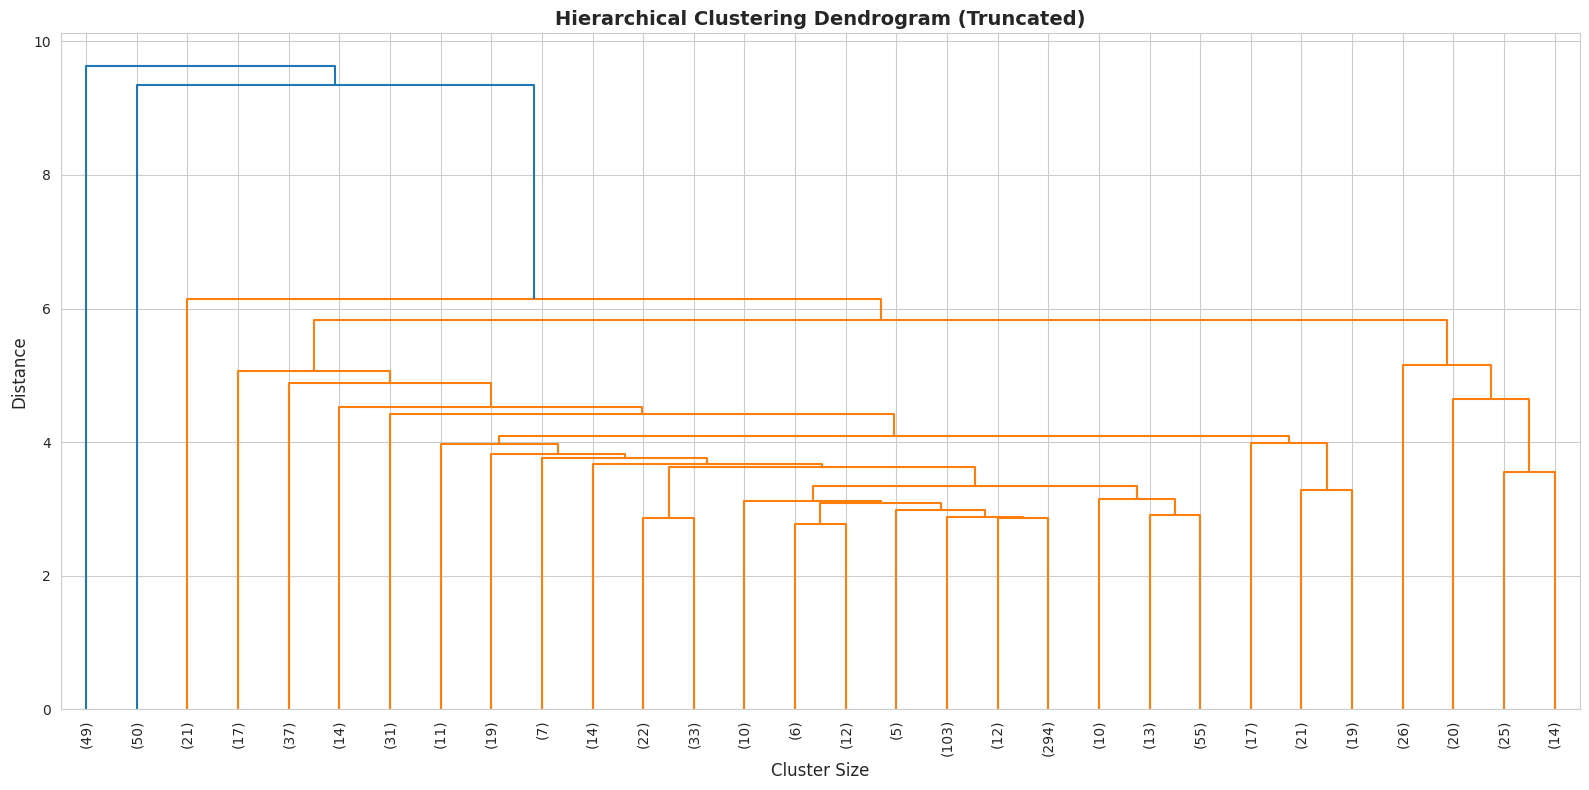

💾 Saved dendrogram to 'dendrogram.png'

🔍 Testing different numbers of clusters...
  k= 2 | Silhouette: 0.248 | Calinski-Harabasz: 99.1
  k= 3 | Silhouette: 0.269 | Calinski-Harabasz: 106.1
  k= 4 | Silhouette: 0.281 | Calinski-Harabasz: 89.4
  k= 5 | Silhouette: 0.227 | Calinski-Harabasz: 80.9
  k= 6 | Silhouette: 0.232 | Calinski-Harabasz: 74.0
  k= 7 | Silhouette: 0.244 | Calinski-Harabasz: 69.8
  k= 8 | Silhouette: 0.216 | Calinski-Harabasz: 66.7
  k= 9 | Silhouette: 0.225 | Calinski-Harabasz: 64.1
  k=10 | Silhouette: 0.235 | Calinski-Harabasz: 62.2
  k=11 | Silhouette: 0.233 | Calinski-Harabasz: 60.7
  k=12 | Silhouette: 0.238 | Calinski-Harabasz: 59.1
  k=13 | Silhouette: 0.242 | Calinski-Harabasz: 57.7
  k=14 | Silhouette: 0.250 | Calinski-Harabasz: 56.7
  k=15 | Silhouette: 0.254 | Calinski-Harabasz: 55.8
  k=16 | Silhouette: 0.263 | Calinski-Harabasz: 55.0
  k=17 | Silhouette: 0.270 | Calinski-Harabasz: 54.3
  k=18 | Silhouette: 0.262 | Calinski-Harabasz: 53.8
  k=19 | Silhou

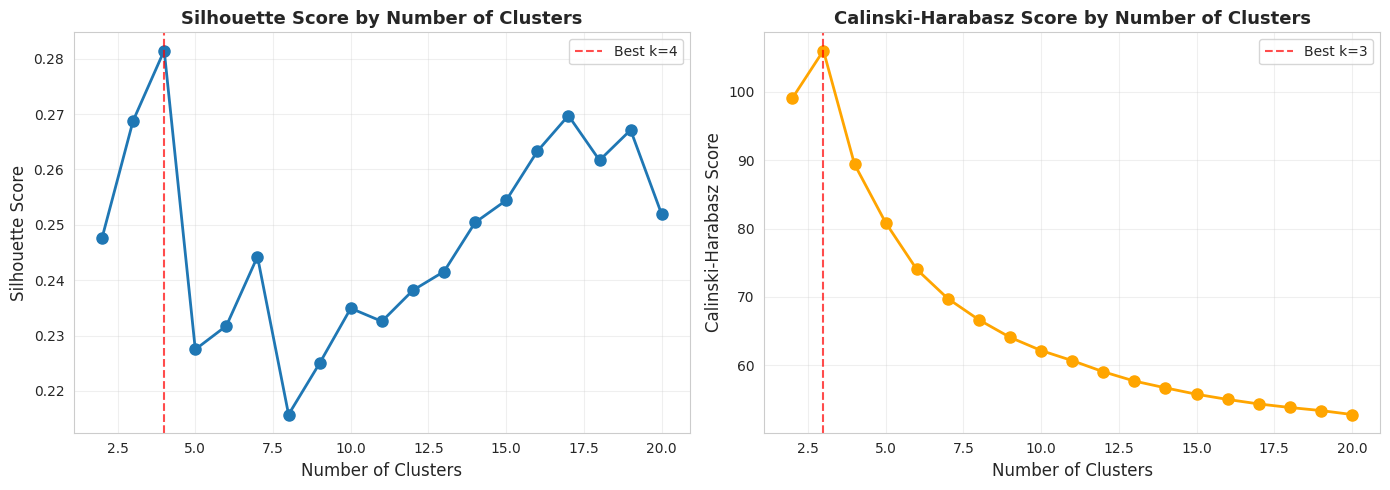

💾 Saved clustering metrics to 'clustering_metrics.png'

🎯 Recommended optimal k: 4 (based on Silhouette Score)
   Alternative k: 3 (based on Calinski-Harabasz Score)


In [24]:
print("\n" + "="*70)
print("🌳 HIERARCHICAL CLUSTERING")
print("="*70)

# Compute linkage matrix
print("Computing linkage matrix (this may take a while)...")
linkage_matrix = linkage(tfidf_reduced, method='ward')
print("✅ Linkage matrix computed")

# Plot dendrogram untuk lihat struktur cluster
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',  # Show only last p merged clusters
           p=30,                    # Show last 30 merges
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved dendrogram to 'dendrogram.png'")

# Test different number of clusters
print("\n🔍 Testing different numbers of clusters...")
silhouette_scores = []
ch_scores = []
k_range = range(2, 21)  # Test dari 2 sampai 20 clusters

for k in k_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = clusterer.fit_predict(tfidf_reduced)
    
    # Compute metrics
    sil_score = silhouette_score(tfidf_reduced, cluster_labels)
    ch_score = calinski_harabasz_score(tfidf_reduced, cluster_labels)
    
    silhouette_scores.append(sil_score)
    ch_scores.append(ch_score)
    
    print(f"  k={k:2d} | Silhouette: {sil_score:.3f} | Calinski-Harabasz: {ch_score:.1f}")

# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, silhouette_scores, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
best_k_sil = k_range[np.argmax(silhouette_scores)]
axes[0].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_sil}')
axes[0].legend()

axes[1].plot(k_range, ch_scores, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1].set_title('Calinski-Harabasz Score by Number of Clusters', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
best_k_ch = k_range[np.argmax(ch_scores)]
axes[1].axvline(best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_ch}')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/clustering_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved clustering metrics to 'clustering_metrics.png'")

# Pilih k optimal (bisa dari silhouette atau CH score, atau kombinasi)
optimal_k = best_k_sil  # Anda bisa ganti ke best_k_ch atau nilai manual
print(f"\n🎯 Recommended optimal k: {optimal_k} (based on Silhouette Score)")
print(f"   Alternative k: {best_k_ch} (based on Calinski-Harabasz Score)")


🎯 APPLYING HIERARCHICAL CLUSTERING (k=4)
✅ Clustering completed with 4 clusters

Cluster distribution:
cluster_hierarchical
0    867
1     21
2     50
3     49
Name: count, dtype: int64


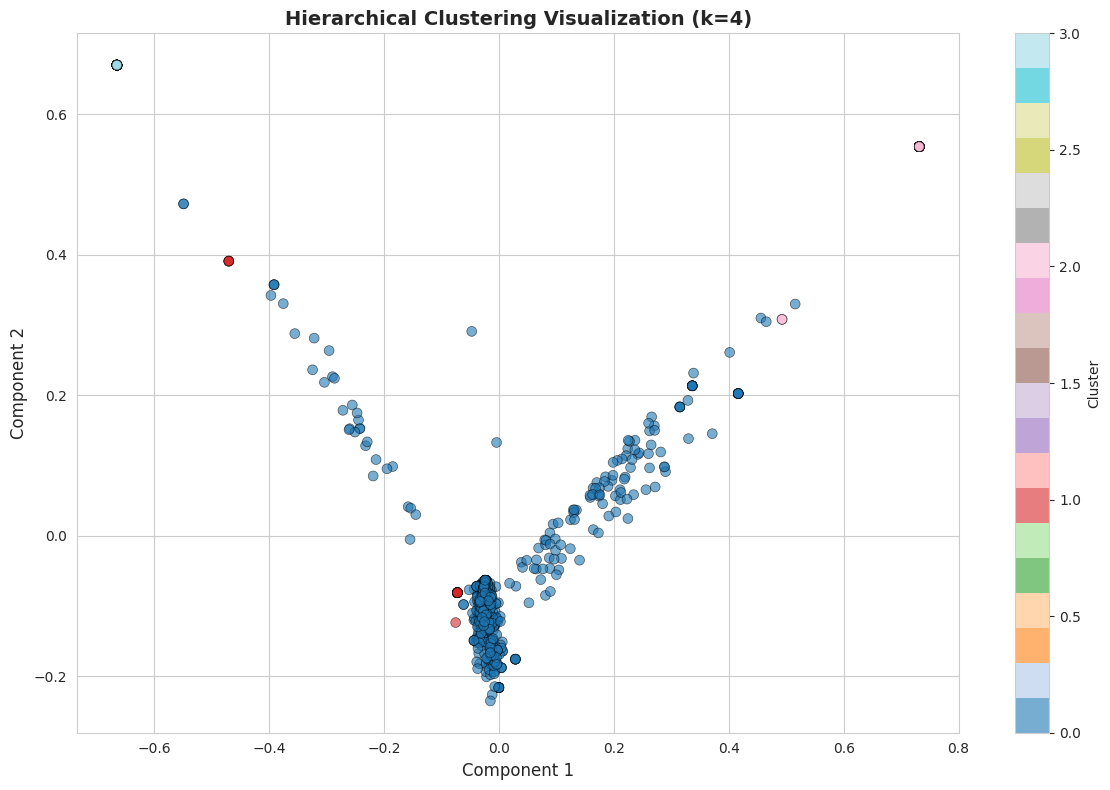

💾 Saved cluster visualization to 'clusters_visualization.png'


In [25]:
print("\n" + "="*70)
print(f"🎯 APPLYING HIERARCHICAL CLUSTERING (k=4)")
print("="*70)

# Apply clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster_hierarchical'] = hierarchical.fit_predict(tfidf_reduced)

print(f"✅ Clustering completed with 4 clusters")
print(f"\nCluster distribution:")
print(df['cluster_hierarchical'].value_counts().sort_index())

# Visualize clusters in 2D
plt.figure(figsize=(12, 8))
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                     c=df['cluster_hierarchical'], 
                     cmap='tab20', 
                     alpha=0.6, 
                     s=50,
                     edgecolors='black',
                     linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Component 1', fontsize=12)
plt.ylabel('Component 2', fontsize=12)
plt.title(f'Hierarchical Clustering Visualization (k=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/clusters_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved cluster visualization to 'clusters_visualization.png'")

In [26]:
feature_names = vectorizer.get_feature_names_out()
print("\n" + "="*70)
print("📋 EXTRACTING TOP TERMS PER CLUSTER")
print("="*70)

def get_top_terms_per_cluster(df, tfidf_matrix, feature_names,
                              cluster_col='cluster_hierarchical', top_n=15):
    """Extract top terms for each cluster based on TF-IDF scores (robust to df index)."""
    clusters = np.unique(df[cluster_col])
    cluster_terms = {}
    n_docs = tfidf_matrix.shape[0]
    print(f"DEBUG: df rows = {len(df)}, tfidf_matrix.shape = {tfidf_matrix.shape}")

    for cluster_id in sorted(clusters):
        # get integer row positions (0..n-1) for documents in this cluster
        positions = np.where(df[cluster_col].values == cluster_id)[0]

        if positions.size == 0:
            continue

        # safety: ensure positions are within tfidf_matrix rows
        if positions.max() >= n_docs:
            raise IndexError(f"Position index {positions.max()} out of range for tfidf_matrix with {n_docs} rows")

        # slice tfidf_matrix by positional indices
        cluster_tfidf = tfidf_matrix[positions].mean(axis=0)

        # convert to 1d numpy array (works for sparse/dense)
        cluster_tfidf_array = np.asarray(cluster_tfidf).ravel()

        # Get top N terms
        top_indices = cluster_tfidf_array.argsort()[-top_n:][::-1]
        top_terms = [(feature_names[i], float(cluster_tfidf_array[i])) for i in top_indices]

        cluster_terms[cluster_id] = top_terms

    return cluster_terms

# Extract top terms
cluster_keywords = get_top_terms_per_cluster(df, tfidf_matrix, feature_names, 
                                             cluster_col='cluster_hierarchical', 
                                             top_n=15)

# Display results
for cluster_id, terms in cluster_keywords.items():
    num_reviews = len(df[df['cluster_hierarchical'] == cluster_id])
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} ({num_reviews} reviews)")
    print(f"{'='*70}")
    print("Top keywords:")
    for term, score in terms:
        print(f"  • {term:25s} (TF-IDF: {score:.4f})")
    
    # Show sample reviews
    print("\nSample reviews (original):")
    sample_reviews = df[df['cluster_hierarchical'] == cluster_id]['content'].head(5).tolist()
    for i, review in enumerate(sample_reviews, 1):
        print(f"  {i}. {review[:150]}...")


📋 EXTRACTING TOP TERMS PER CLUSTER
DEBUG: df rows = 987, tfidf_matrix.shape = (987, 500)

CLUSTER 0 (867 reviews)
Top keywords:
  • sangat                    (TF-IDF: 0.0613)
  • shopee                    (TF-IDF: 0.0562)
  • bagus                     (TF-IDF: 0.0397)
  • belanja                   (TF-IDF: 0.0381)
  • baik                      (TF-IDF: 0.0376)
  • aplikasi                  (TF-IDF: 0.0331)
  • kirim                     (TF-IDF: 0.0304)
  • bantu                     (TF-IDF: 0.0302)
  • barang                    (TF-IDF: 0.0279)
  • sangat bantu              (TF-IDF: 0.0246)
  • mudah                     (TF-IDF: 0.0245)
  • banget                    (TF-IDF: 0.0239)
  • kasih                     (TF-IDF: 0.0189)
  • terima                    (TF-IDF: 0.0182)
  • sangat bagus              (TF-IDF: 0.0179)

Sample reviews (original):
  1. aplikasi shopee ini sangat bagus karena. bisa mempermudah kita jika ingin belanja namun malas keluar rumah dan gratis ongkir lagi pok

In [27]:
print("\n" + "="*70)
print("💾 EXPORTING RESULTS")
print("="*70)

# Save cluster keywords to CSV
cluster_keywords_df = []
for cluster_id, terms in cluster_keywords.items():
    for rank, (term, score) in enumerate(terms, 1):
        cluster_keywords_df.append({
            'cluster_id': cluster_id,
            'rank': rank,
            'term': term,
            'tfidf_score': score
        })

cluster_keywords_df = pd.DataFrame(cluster_keywords_df)
cluster_keywords_df.to_csv('/kaggle/working/cluster_keywords.csv', index=False, encoding='utf-8-sig')
print("✅ Saved cluster keywords to 'cluster_keywords.csv'")

# Save full results with cluster assignments
df_export = df[['reviewId', 'content', 'content_cleaned', 'score', 'cluster_hierarchical']].copy()
df_export = df_export.rename(columns={'cluster_hierarchical': 'cluster'})

# Add top 5 keywords for each review's cluster
df_export['cluster_keywords'] = df_export['cluster'].apply(
    lambda x: ', '.join([term for term, _ in cluster_keywords[x][:5]])
)

df_export.to_csv('/kaggle/working/reviews_with_clusters.csv', index=False, encoding='utf-8-sig')
print("✅ Saved reviews with cluster assignments to 'reviews_with_clusters.csv'")

# Create summary per cluster
cluster_summary = []
for cluster_id in sorted(df['cluster_hierarchical'].unique()):
    cluster_data = df[df['cluster_hierarchical'] == cluster_id]
    summary = {
        'cluster_id': cluster_id,
        'num_reviews': len(cluster_data),
        'avg_score': cluster_data['score'].mean(),
        'top_5_keywords': ', '.join([term for term, _ in cluster_keywords[cluster_id][:5]]),
        'sample_review': cluster_data['content'].iloc[0][:200] if len(cluster_data) > 0 else ''
    }
    cluster_summary.append(summary)

cluster_summary_df = pd.DataFrame(cluster_summary)
cluster_summary_df.to_csv('/kaggle/working/cluster_summary.csv', index=False, encoding='utf-8-sig')
print("✅ Saved cluster summary to 'cluster_summary.csv'")

print("\n" + "="*70)
print("✅ CLUSTERING PIPELINE COMPLETED!")
print("="*70)
print("\n📊 Generated files:")
print("  1. reviews_preprocessed.csv - Preprocessed reviews")
print("  2. tfidf_terms.csv - All TF-IDF terms with scores")
print("  3. dendrogram.png - Hierarchical clustering dendrogram")
print("  4. clustering_metrics.png - Metrics for different k values")
print("  5. clusters_visualization.png - 2D visualization of clusters")
print("  6. cluster_keywords.csv - Top keywords per cluster")
print("  7. reviews_with_clusters.csv - All reviews with cluster assignments")
print("  8. cluster_summary.csv - Summary per cluster")
print("\n📝 Next steps:")
print("  1. Review 'cluster_summary.csv' untuk overview setiap cluster")
print("  2. Review 'cluster_keywords.csv' untuk lihat keyword per cluster")
print("  3. Manual labeling: tentukan aspect name untuk setiap cluster")
print("  4. Filter cluster yang relevan dengan e-commerce")
print("  5. Create seed keywords untuk Phase 2 scraping")


💾 EXPORTING RESULTS
✅ Saved cluster keywords to 'cluster_keywords.csv'
✅ Saved reviews with cluster assignments to 'reviews_with_clusters.csv'
✅ Saved cluster summary to 'cluster_summary.csv'

✅ CLUSTERING PIPELINE COMPLETED!

📊 Generated files:
  1. reviews_preprocessed.csv - Preprocessed reviews
  2. tfidf_terms.csv - All TF-IDF terms with scores
  3. dendrogram.png - Hierarchical clustering dendrogram
  4. clustering_metrics.png - Metrics for different k values
  5. clusters_visualization.png - 2D visualization of clusters
  6. cluster_keywords.csv - Top keywords per cluster
  7. reviews_with_clusters.csv - All reviews with cluster assignments
  8. cluster_summary.csv - Summary per cluster

📝 Next steps:
  1. Review 'cluster_summary.csv' untuk overview setiap cluster
  2. Review 'cluster_keywords.csv' untuk lihat keyword per cluster
  3. Manual labeling: tentukan aspect name untuk setiap cluster
  4. Filter cluster yang relevan dengan e-commerce
  5. Create seed keywords untuk Phas

In [ ]:
import numpy as _np
def calculate_hierarchical_clustering(X_reduced):
    """
    Implementasi Persamaan 2.9 - 2.19
    Hierarchical Clustering dengan evaluasi
    """
    
    print("\n" + "="*100)
    print("BAGIAN 2: HIERARCHICAL CLUSTERING")
    print("Persamaan 2.9 - 2.19")
    print("="*100)
    
    # Persamaan 2.9: Euclidean Distance
    print("\n" + "-"*100)
    print("PERSAMAAN 2.9: Euclidean Distance")
    print("d(x_i, x_j) = √(Σ(x_il - x_jl)²)")
    print("-"*100)
    
    x_0 = X_reduced[0]
    x_1 = X_reduced[1]
    diff = x_0 - x_1
    squared = diff ** 2
    sum_sq = np.sum(squared)
    distance = np.sqrt(sum_sq)
    
    print(f"\nJarak antara Dok-0 dan Dok-1:")
    print(f"  Contoh dimensi 0: ({x_0[0]:.4f} - {x_1[0]:.4f})² = {squared[0]:.6f}")
    print(f"  Σ(squared diff) = {sum_sq:.6f}")
    print(f"  d = √{sum_sq:.6f} = {distance:.6f}")
    
    # Clustering dengan k=4
    k = 4
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = hierarchical.fit_predict(X_reduced)
    
    print(f"\nClustering dengan k={k}:")
    for c in range(k):
        count = np.sum(cluster_labels == c)
        print(f"  Cluster {c}: {count} dokumen")
    
    # Persamaan 2.10: Centroid
    print("\n" + "-"*100)
    print("PERSAMAAN 2.10: Cluster Centroid")
    print("μ_C = (1/n_C) Σ x_i")
    print("-"*100)
    
    cluster_id = 0
    mask = cluster_labels == cluster_id
    points = X_reduced[mask]
    n_C = len(points)
    mu_C = np.mean(points, axis=0)
    
    print(f"\nCluster {cluster_id}:")
    print(f"  n_C = {n_C} dokumen")
    print(f"  μ_C[0] = (1/{n_C}) × Σ x[i,0] = {mu_C[0]:.6f}")
    # indeks dokumen di cluster 0
    idxs = np.where(cluster_labels == 0)[0]
    
    # nilai kolom-0 untuk dokumen cluster 0
    vals_col0 = X_reduced[idxs, 0]
    
    print("n_C =", len(idxs))
    print("10 nilai pertama kolom 0:", vals_col0[:10])
    print("sum =", vals_col0.sum())
    print("mean =", vals_col0.mean())
    print("std  =", vals_col0.std())
    
    # jumlah dimensi (jumlah elemen tiap vektor fitur)
    d = X_reduced.shape[1]
    
    # x0: dokumen indeks 0 (vektor)
    x0 = X_reduced[0]
    
    # mu_global (μ) — jika nanti sudah dihitung lagi di bawah, penghitungan ulang ini aman
    mu_global = np.mean(X_reduced, axis=0)
    
    # hitung/jelaskan berapa banyak elemen (count) pada tiap vektor
    print(f"  dimensi (d) = {d}")
    print(f"  jumlah elemen μ_C     = {mu_C.shape[0]}")
    print(f"  jumlah elemen x0      = {x0.shape[0]}")
    print(f"  jumlah elemen μ (global) = {mu_global.shape[0]}")
    
    # tampilkan 5 sampel pertama (ringkasan)
    print(f"  5 sampel pertama μ_C   = {np.round(mu_C[:5], 6)}")
    print(f"  5 sampel pertama x0    = {np.round(x0[:5], 6)}")
    print(f"  5 sampel pertama μ (global) = {np.round(mu_global[:5], 6)}")

    # Persamaan 2.11: WCSS
    print("\n" + "-"*100)
    print("PERSAMAAN 2.11: Within-Cluster Sum of Squares (WCSS)")
    print("WCSS(C) = Σ ||x_i - μ_C||²")
    print("-"*100)
    
    wcss = 0
    for i, idx in enumerate(np.where(mask)[0][:3]):   # tetap 3 dokumen contoh
        x_vec = X_reduced[idx]
        diff_vec = x_vec - mu_C
        dist = np.linalg.norm(diff_vec)
        sq_dist = dist ** 2
    
        print(f"\n  Dok {idx}:")
        print(f"    x[{idx}][:5]   = {np.round(x_vec[:5], 6)}")
        print(f"    μ_C[:5]        = {np.round(mu_C[:5], 6)}")
        print(f"    (x - μ)[:5]    = {np.round(diff_vec[:5], 6)}")
        print(f"    ||x - μ||      = {dist:.6f}")
        print(f"    ||x - μ||^2    = {sq_dist:.6f}")
    
    wcss_total = np.sum([np.linalg.norm(x - mu_C)**2 for x in points])
    print(f"  WCSS total = {wcss_total:.6f}")
    
    
    # Persamaan 2.12: Ward Linkage
    print("\n" + "-"*100)
    print("PERSAMAAN 2.12: Ward Linkage Δ(A,B)")
    print("Δ(A,B) = WCSS(A∪B) - WCSS(A) - WCSS(B)")
    print("-"*100)
    
    mask_A = cluster_labels == 0
    mask_B = cluster_labels == 1
    points_A = X_reduced[mask_A]
    points_B = X_reduced[mask_B]
    
    mu_A = np.mean(points_A, axis=0)
    mu_B = np.mean(points_B, axis=0)
    wcss_A = np.sum([np.linalg.norm(x - mu_A)**2 for x in points_A])
    wcss_B = np.sum([np.linalg.norm(x - mu_B)**2 for x in points_B])
    
    points_AB = np.vstack([points_A, points_B])
    mu_AB = np.mean(points_AB, axis=0)
    wcss_AB = np.sum([np.linalg.norm(x - mu_AB)**2 for x in points_AB])
    
    delta = wcss_AB - wcss_A - wcss_B
    
    print(f"\nΔ(Cluster 0, Cluster 1):")
    print(f"  WCSS(A) = {wcss_A:.6f}")
    print(f"  WCSS(B) = {wcss_B:.6f}")
    print(f"  WCSS(A∪B) = {wcss_AB:.6f}")
    print(f"  Δ = {wcss_AB:.6f} - {wcss_A:.6f} - {wcss_B:.6f} = {delta:.6f}")
    
    # Persamaan 2.13-2.14: Silhouette a(i) dan b(i)
    print("\n" + "-"*100)
    print("PERSAMAAN 2.13-2.14: Silhouette a(i) dan b(i)")
    print("-"*100)
    
    sample_idx = 0
    sample_cluster = cluster_labels[sample_idx]
    
    # a(i)
    same_mask = (cluster_labels == sample_cluster) & (np.arange(len(cluster_labels)) != sample_idx)
    same_points = X_reduced[same_mask]
    distances_same = [np.linalg.norm(X_reduced[sample_idx] - p) for p in same_points]
    a_i = np.mean(distances_same) if len(distances_same) > 0 else 0
    
    print(f"\nDokumen {sample_idx} (Cluster {sample_cluster}):")
    print(f"  a(i) = rata-rata jarak dalam cluster")
    print(f"  Contoh jarak: {distances_same[:3]}")
    print(f"  a(i) = {a_i:.6f}")
    
    # b(i)
    other_clusters = [c for c in range(k) if c != sample_cluster]
    min_dist = float('inf')
    for c in other_clusters:
        other_points = X_reduced[cluster_labels == c]
        avg_dist = np.mean([np.linalg.norm(X_reduced[sample_idx] - p) for p in other_points])
        if avg_dist < min_dist:
            min_dist = avg_dist
            nearest_cluster = c
    
    b_i = min_dist
    print(f"\n  b(i) = rata-rata jarak ke cluster terdekat")
    print(f"  Cluster terdekat: {nearest_cluster}")
    print(f"  b(i) = {b_i:.6f}")
    
    # Persamaan 2.15-2.16: Silhouette Score
    sample_idx = 0
    sample_cluster = cluster_labels[sample_idx]
    idxs_same_cluster = np.where(cluster_labels == sample_cluster)[0]
    idxs_same_cluster = idxs_same_cluster[idxs_same_cluster != sample_idx]  # exclude sample itself
    # a(i) — per-dokumen distances inside same cluster
    distances_same = []
    print(f"\nDokumen {sample_idx} (Cluster {sample_cluster}): menghitung a(i)")
    for j, idx in enumerate(idxs_same_cluster[:10]):  # tampilkan up to 10 jarak contoh
        d_j = np.linalg.norm(X_reduced[sample_idx] - X_reduced[idx])
        distances_same.append(d_j)
        print(f"  jarak ke dok {idx}: ||x[{sample_idx}] - x[{idx}]|| = {d_j:.6f}")
    
    # rata-rata a(i)
    if len(distances_same) > 0:
        a_i = np.mean(distances_same)
        print(f"  a(i) = mean({[round(v,6) for v in distances_same]}) = {a_i:.6f}")
    else:
        a_i = 0
        print("  a(i) = 0 (tidak ada anggota lain di cluster)")
    
    # b(i) — rata-rata jarak ke setiap cluster lain, lalu pilih minimum
    other_clusters = [c for c in range(k) if c != sample_cluster]
    avg_dists_per_cluster = {}
    print(f"\nMenghitung rata-rata jarak dari dokumen {sample_idx} ke tiap cluster lain (b(i) candidates):")
    for c in other_clusters:
        other_idxs = np.where(cluster_labels == c)[0]
        if other_idxs.size == 0:
            avg_dist = np.nan
            print(f"  Cluster {c}: kosong")
        else:
            dists = [np.linalg.norm(X_reduced[sample_idx] - X_reduced[idx]) for idx in other_idxs]
            avg_dist = np.mean(dists)
            # tampilkan beberapa contoh jarak (maks 6) untuk cluster c
            sample_dists = [round(v,6) for v in (dists[:6])]
            print(f"  Cluster {c}: n={len(other_idxs)}, contoh jarak={sample_dists} ..., rata-rata = {avg_dist:.6f}")
        avg_dists_per_cluster[c] = avg_dist
    
    # pilih cluster terdekat
    nearest_cluster = min(avg_dists_per_cluster, key=lambda cc: avg_dists_per_cluster[cc])
    b_i = avg_dists_per_cluster[nearest_cluster]
    print(f"\nCluster terdekat untuk dok {sample_idx} = {nearest_cluster} dengan b(i) = {b_i:.6f}")
    
    # s(i) per-step
    print("\n" + "-"*40)
    print("PERSAMAAN 2.15-2.16: Silhouette Score per-step")
    print("s(i) = (b(i) - a(i)) / max{a(i), b(i)}")
    print("-"*40)
    print(f"  a(i) = {a_i:.6f}")
    print(f"  b(i) = {b_i:.6f}")
    numerator = (b_i - a_i)
    denominator = max(a_i, b_i) if max(a_i, b_i) != 0 else np.nan
    s_i = numerator / denominator if denominator != 0 else 0
    print(f"  numerator = b(i) - a(i) = {b_i:.6f} - {a_i:.6f} = {numerator:.6f}")
    print(f"  denominator = max(a(i), b(i)) = {denominator:.6f}")
    print(f"  s({sample_idx}) = {numerator:.6f} / {denominator:.6f} = {s_i:.6f}")
    
    # Global silhouette (unchanged) — tampilkan juga ringkasan per-cluster mean s
    S = silhouette_score(X_reduced, cluster_labels)
    print(f"\nS (global) = (1/N) Σ s(i) = {S:.6f}")
    
    # Persamaan 2.17-2.19: Calinski-Harabasz
    print("\n" + "-"*100)
    print("PERSAMAAN 2.17-2.19: Calinski-Harabasz Index")
    print("-"*100)
    
    mu_global = np.mean(X_reduced, axis=0)
    n = len(X_reduced)
    
    # BCSS & wcss
    bcss = 0
    wcss_total_all = 0
    print("\nPer-cluster detail (n_k, ||μ_k - μ||^2, contribution n_k * ||μ_k - μ||^2, WCSS_k):")
    for c in range(k):
        mask_c = cluster_labels == c
        idxs_c = np.where(mask_c)[0]
        n_c = len(idxs_c)
        if n_c == 0:
            mu_c = np.zeros(mu_global.shape)
            norm_sq = 0.0
            wcss_c = 0.0
        else:
            mu_c = np.mean(X_reduced[mask_c], axis=0)
            diff_mu = mu_c - mu_global
            norm_sq = np.linalg.norm(diff_mu)**2
            wcss_c = np.sum([np.linalg.norm(X_reduced[idx] - mu_c)**2 for idx in idxs_c])
    
        contrib = n_c * norm_sq
        bcss += contrib
        wcss_total_all += wcss_c
    
        # print per-cluster breakdown (ringkasan)
        print(f"  Cluster {c}: n_k={n_c}")
        print(f"    μ_k[:5] = {np.round(mu_c[:5],6)}")
        print(f"    ||μ_k - μ||^2 = {norm_sq:.6f}")
        print(f"    n_k * ||μ_k - μ||^2 = {contrib:.6f}")
        print(f"    WCSS_k = {wcss_c:.6f}")
    
    # totals and CH calculation (show intermediate division)
    print(f"\nBCSS (sum n_k ||μ_k - μ||^2) = {bcss:.6f}")
    print(f"WCSS (sum per-cluster WCSS_k) = {wcss_total_all:.6f}")
    
    # CH index
    numerator_ch = bcss / (k - 1)
    denominator_ch = wcss_total_all / (n - k)
    ch = numerator_ch / denominator_ch if denominator_ch != 0 else np.nan
    
    print(f"\nCH(k) = (BCSS/(k-1)) / (WCSS/(n-k))")
    print(f"  BCSS/(k-1) = {bcss:.6f} / {k-1} = {numerator_ch:.6f}")
    print(f"  WCSS/(n-k) = {wcss_total_all:.6f} / {n-k} = {denominator_ch:.6f}")
    print(f"  CH({k}) = {numerator_ch:.6f} / {denominator_ch:.6f} = {ch:.6f}")

cluster_labels=calculate_hierarchical_clustering(X_reduced)


BAGIAN 2: HIERARCHICAL CLUSTERING
Persamaan 2.9 - 2.19

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.9: Euclidean Distance
d(x_i, x_j) = √(Σ(x_il - x_jl)²)
----------------------------------------------------------------------------------------------------

Jarak antara Dok-0 dan Dok-1:
  Contoh dimensi 0: (0.3675 - 0.0555)² = 0.097345
  Σ(squared diff) = 1.068522
  d = √1.068522 = 1.033694

Clustering dengan k=4:
  Cluster 0: 865 dokumen
  Cluster 1: 21 dokumen
  Cluster 2: 52 dokumen
  Cluster 3: 49 dokumen

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.10: Cluster Centroid
μ_C = (1/n_C) Σ x_i
----------------------------------------------------------------------------------------------------

Cluster 0:
  n_C = 865 dokumen
  μ_C[0] = (1/865) × Σ x[i,0] = 0.076184

  n_C = 865
  10 nilai pertama kolom 0:
    [3.67491145e-01 5.54899906e-02 3.35782285e